🏠 Real Estate Dataset — Data Cleaning & Preprocessing

📌 Overview

In this section, we clean and prepare the real estate dataset for further analysis and machine learning.


The main steps include:


Removing duplicate records.

Handling missing values.

Converting data types when necessary.

Reviewing unusual values in price, area, bedrooms, and bathrooms.

Removing irrelevant columns such as IDs, URLs, and agent/broker contact information.

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

In [2]:
import os
import kagglehub
import pandas as pd

dataset_path = kagglehub.dataset_download("waddahali/real-estate-listings")

csv_file_path = os.path.join(dataset_path, "propertyfinder.csv")

df = pd.read_csv(csv_file_path, low_memory=False)

print("Loaded dataset:", df.shape)

c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded dataset: (39713, 53)


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 39713 entries, 0 to 39712
Data columns (total 53 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   listing_id           39712 non-null  str    
 1   internal_id          39712 non-null  float64
 2   category             39713 non-null  str    
 3   listing_type         39713 non-null  str    
 4   detail_url           39712 non-null  str    
 5   property_type        39712 non-null  str    
 6   offering_type        39712 non-null  str    
 7   completion_status    19763 non-null  str    
 8   title                39712 non-null  str    
 9   price_egp            39712 non-null  float64
 10  price_period         39712 non-null  str    
 11  price_currency       39713 non-null  str    
 12  location_full        39712 non-null  str    
 13  city                 39712 non-null  str    
 14  town                 39712 non-null  str    
 15  district             39366 non-null  str    
 1

In [4]:
df.shape

(39713, 53)

In [5]:
df.head()

,listing_id,internal_id,category,listing_type,detail_url,property_type,offering_type,completion_status,title,price_egp,...,agent_is_super,agent_languages,broker_id,broker_name,broker_email,broker_phone,contact_phone,contact_whatsapp,contact_email,scraped_at
0,F7QB31CGWE509V2W7DF2GARB2C,56009081.0,buy,property,https://www.propertyfinder.eg/en/plp/buy/duple...,Duplex,Residential for Sale,completed,Garden Villa - Lake View Boutique - Prime Loca...,24500000.0,...,False,NaN,5758.0,Spade consultancy,mohmedg.sedik@gmail.com,1.001437e+09,2.012018e+11,2.022126e+10,pierre.Osama@spade-consultancy.com,2026-03-04T14:20:33.281007
1,K1JC3D6N57ED52N3VX1QQKHHXG,56247925.0,buy,property,https://www.propertyfinder.eg/en/plp/buy/apart...,Apartment,Residential for Sale,off_plan,For Sale: Finished Apartment+ ACs in Village West,5145000.0,...,False,NaN,492.0,Abrag Real Estate,snawara71@gmail.com,2.010012e+11,2.010072e+11,2.022126e+10,ranoushamer901@gmail.com,2026-03-04T14:20:33.281007
2,Q6GEB8T6PZTJGNNPWA5PX3JCWR,56253883.0,buy,property,https://www.propertyfinder.eg/en/plp/buy/apart...,Apartment,Residential for Sale,completed,UnderMarket Price for Apt. 250 RTM PrimeLocation,10800000.0,...,False,English | Arabic,5279.0,Premises,mahmouddessam@hotmail.com,2.010051e+11,2.010910e+11,2.022126e+10,ashrafsobhy99@hotmail.com,2026-03-04T14:20:33.281007
3,PPH0852SAB266X6GSVATJP4F0M,56250852.0,buy,property,https://www.propertyfinder.eg/en/plp/buy/apart...,Apartment,Residential for Sale,completed,lowest price 2bds fullyfurnished @ lake view,10500000.0,...,False,NaN,5758.0,Spade consultancy,mohmedg.sedik@gmail.com,1.001437e+09,2.010701e+11,2.022126e+10,ebrahim.hossam@spade-consultancy.com,2026-03-04T14:20:33.281007
4,QCSA4TNDEBBV7BNY8ANST3TB50,55995764.0,buy,property,https://www.propertyfinder.eg/en/plp/buy/villa...,Villa,Residential for Sale,completed,Exclusive Type M with Lowest Price RTM in PNC,19500000.0,...,False,English | Arabic,5279.0,Premises,mahmouddessam@hotmail.com,2.010051e+11,2.010910e+11,2.022126e+10,ashrafsobhy99@hotmail.com,2026-03-04T14:20:33.281007


In [6]:
df.tail()

,listing_id,internal_id,category,listing_type,detail_url,property_type,offering_type,completion_status,title,price_egp,...,agent_is_super,agent_languages,broker_id,broker_name,broker_email,broker_phone,contact_phone,contact_whatsapp,contact_email,scraped_at
39708,YQT77A2J44CPMV7H28J9V30ADR,8667639.0,rent,property,https://www.propertyfinder.eg/en/plp/rent/apar...,Apartment,Residential for Rent,NaN,"Furnished apartment for rent in Al Rehab, 250M",55000.0,...,False,NaN,4456.0,Escan Group,aahmdymagdy201070@gmail.com,2.011233e+11,2.011040e+11,2.022126e+10,atiasaad188@gmail.com,2026-03-05T00:43:04.172513
39709,8385GKAA00BXE8FYPWNQ29VF3M,8667632.0,rent,property,https://www.propertyfinder.eg/en/plp/rent/apar...,Apartment,Residential for Rent,NaN,FULLY FURNISHED apartment for RENT 3 Bedroom,45000.0,...,False,NaN,430.0,RE/MAX Al Mohager,m.degheady@remax.com.eg,2.010308e+11,2.010947e+11,2.022126e+10,yuliya.hassan@remax.com.eg,2026-03-05T00:43:04.172513
39710,R9PTSC3V5RZ77ZT9X69TBE1PEC,8667625.0,rent,property,https://www.propertyfinder.eg/en/plp/rent/town...,Townhouse,Residential for Rent,NaN,Furnished villa for rent in Town 5 rooms near New,120000.0,...,False,NaN,4679.0,Abrag 2,NaN,NaN,2.011146e+11,2.022126e+10,Mahmoudalabasy94@gmail.com,2026-03-05T00:43:04.172513
39711,9Q295E8B6ET3V30Z31925BR6ZG,8667615.0,rent,property,https://www.propertyfinder.eg/en/plp/rent/apar...,Apartment,Residential for Rent,NaN,For Rent – Premium 196m² Fully Finished Apartment,50000.0,...,False,NaN,430.0,RE/MAX Al Mohager,m.degheady@remax.com.eg,2.010308e+11,2.010707e+11,2.022126e+10,yalashwat2000@gmail.com,2026-03-05T00:43:04.172513
39712,HYEPN5XPWQT7K05K4ST7EDWW5R,8667602.0,rent,property,https://www.propertyfinder.eg/en/plp/rent/apar...,Apartment,Residential for Rent,NaN,If you're looking hotel units contact us now,75000.0,...,False,English | Arabic,5307.0,Smart Home,ahmedbompo9@gmail.com,2.010120e+11,2.010408e+11,2.022126e+10,sh2927333@gmail.com,2026-03-05T00:43:04.172513


2. Check for Duplicate Values

In [7]:
print("Full duplicated rows:", df.duplicated().sum())

Full duplicated rows: 0


In [8]:
df = df.drop_duplicates().copy()

In [9]:
print("Full duplicated rows:", df.duplicated().sum())

Full duplicated rows: 0


3. Handle Missing Values

In [10]:
df.isnull().sum()

listing_id                 1
internal_id                1
category                   0
listing_type               0
detail_url                 1
property_type              1
offering_type              1
completion_status      19950
title                      1
price_egp                  1
price_period               1
price_currency             0
location_full              1
city                       1
town                       1
district                 347
subdistrict             6759
lat                        1
lon                        1
bedrooms                  35
bathrooms                 30
area_value                 1
area_unit                  0
furnished               8385
listing_level              1
is_premium                 0
is_verified                0
is_featured                0
is_new_construction        0
is_direct_from_dev         0
is_exclusive               0
listed_date                1
images_count               0
has_view_360               0
video_url     

In [11]:
df=df.drop(columns=['video_url','rera','agent_languages'])

In [12]:
df['completion_status'] = df['completion_status'].fillna('Unknown')
df['district'] = df['district'].fillna('Unknown')
df['subdistrict'] = df['subdistrict'].fillna('Unknown')
df['furnished'] = df['furnished'].fillna('Unknown')
df['payment_method'] = df['payment_method'].fillna('Unknown')
df['title'] = df['title'].fillna('Unknown')
df['location_full'] = df['location_full'].fillna('Unknown')
df['reference'] = df['reference'].fillna('Unknown')
df['description'] = df['description'].fillna('Unknown')
df['amenities'] = df['amenities'].fillna('Unknown')

In [13]:
df['listed_date'] = pd.to_datetime(df['listed_date'])

In [14]:
print(df['listed_date'].value_counts())

listed_date
2026-02-09 11:27:08+00:00    13
2026-03-04 12:12:21+00:00    11
2026-03-04 11:52:42+00:00    10
2026-03-03 12:16:32+00:00    10
2026-02-10 13:23:33+00:00    10
                             ..
2026-02-07 16:33:32+00:00     1
2026-02-07 16:32:23+00:00     1
2026-02-07 16:31:32+00:00     1
2026-02-07 16:29:24+00:00     1
2026-02-07 16:26:50+00:00     1
Name: count, Length: 36255, dtype: int64


In [15]:
df.isnull().sum()

listing_id               1
internal_id              1
category                 0
listing_type             0
detail_url               1
property_type            1
offering_type            1
completion_status        0
title                    0
price_egp                1
price_period             1
price_currency           0
location_full            0
city                     1
town                     1
district                 0
subdistrict              0
lat                      1
lon                      1
bedrooms                35
bathrooms               30
area_value               1
area_unit                0
furnished                0
listing_level            1
is_premium               0
is_verified              0
is_featured              0
is_new_construction      0
is_direct_from_dev       0
is_exclusive             0
listed_date              1
images_count             0
has_view_360             0
reference                0
description              0
amenities                0
p

In [16]:
df['reference']

0        F7QB31CGWE509V2W7DF2GARB2C
1                             rb304
2                         250pncash
3        PPH0852SAB266X6GSVATJP4F0M
4                           VillTyM
                    ...            
39708                     CVU146900
39709    8385GKAA00BXE8FYPWNQ29VF3M
39710    R9PTSC3V5RZ77ZT9X69TBE1PEC
39711    9Q295E8B6ET3V30Z31925BR6ZG
39712    HYEPN5XPWQT7K05K4ST7EDWW5R
Name: reference, Length: 39713, dtype: str

In [17]:
df = df.drop(columns=[
    'listing_id',
    'internal_id',
    'detail_url',
    'agent_id',
    'agent_name',
    'agent_email',
    'broker_id',
    'broker_name',
    'broker_email',
    'broker_phone',
    'contact_phone',
    'contact_whatsapp',
    'contact_email'
], errors='ignore')

## Modeling Handoff — Data Quality Gate

Before the cleaned data is passed to modeling, we run two final checks that depend on raw listing text/identifiers. These checks are used for data quality only and are **not** predictive features.

- Exact duplicate rows are checked after the team cleaning step.
- Repeated listing references are audited but are not automatically removed because `reference` is not guaranteed to be a unique listing key.
- For the rental market, records whose `title` clearly conflicts with a rent label or whose monthly price exceeds the project quality-control threshold are flagged and removed before modeling.

This is a quality-control step, not blanket statistical outlier removal. Legitimate high-value properties remain eligible for modeling.

In [18]:
# Final data-quality gate before identifier/text columns are dropped

print("Exact duplicate rows after cleaning:", int(df.duplicated().sum()))

if "reference" in df.columns:
    ref = df["reference"].dropna()
    print("Rows associated with duplicated non-null references:", int(ref.duplicated(keep=False).sum()))
    print("Unique non-null references:", int(ref.nunique()))

# Rental market consistency audit
rent_mask = df["category"].eq("rent")
title_text = df["title"].fillna("").astype(str).str.lower()
sale_keyword_mask = title_text.str.contains(
    r"\bfor sale\b|\bsale\b|\bsell\b|للبيع",
    regex=True
)
extreme_rent_mask = df["price_egp"].gt(2_000_000)
rent_quality_issue = rent_mask & (sale_keyword_mask | extreme_rent_mask)

print("\nRent quality audit")
print("  Rent rows flagged as inconsistent/extreme:", int(rent_quality_issue.sum()))
print("  Rows with sale-related title keywords:", int((rent_mask & sale_keyword_mask).sum()))
print("  Rows with monthly rent > 2,000,000 EGP:", int((rent_mask & extreme_rent_mask).sum()))

# Keep the original team cleaning, then pass only quality-controlled rows to modeling.
df = df.loc[~rent_quality_issue].copy()

print("Rows after rental quality gate:", len(df))

Exact duplicate rows after cleaning: 0
Rows associated with duplicated non-null references: 126
Unique non-null references: 39646

Rent quality audit
  Rent rows flagged as inconsistent/extreme: 127
  Rows with sale-related title keywords: 94
  Rows with monthly rent > 2,000,000 EGP: 61
Rows after rental quality gate: 39586


In [19]:
df = df.drop(columns=[
    'price_currency',
    'payment_method',
    'title',
    'area_unit',
    'reference',
    'description'
], errors='ignore')

In [20]:
df.shape

(39586, 31)

In [21]:
print(df['bedrooms'].unique())

<StringArray>
['3', '2', '4', nan, '6', '5', 'studio', '7', '1', '7+']
Length: 10, dtype: str


In [22]:
df['bedrooms']=df['bedrooms'].replace({'studio':'0','7+':'7'})

In [23]:
print(df['bedrooms'].unique())

<StringArray>
['3', '2', '4', nan, '6', '5', '0', '7', '1']
Length: 9, dtype: str


In [24]:
df['bedrooms'] = pd.to_numeric(df['bedrooms'])

In [25]:
print(df['bathrooms'].unique())

<StringArray>
['6', '2', '4', nan, '1', '3', '7+', '5', '7', 'none']
Length: 10, dtype: str


In [26]:
df['bathrooms']=df['bathrooms'].replace({'none':'0','7+':'7'})

In [27]:
print(df['bathrooms'].unique())

<StringArray>
['6', '2', '4', nan, '1', '3', '7', '5', '0']
Length: 9, dtype: str


In [28]:
df['bathrooms'] = pd.to_numeric(df['bathrooms'])

In [29]:
df['property_type'] = df['property_type'].fillna('Unknown')
df['offering_type'] = df['offering_type'].fillna('Unknown')
df['price_period'] = df['price_period'].fillna('Unknown')
df['city'] = df['city'].fillna('Unknown')
df['town'] = df['town'].fillna('Unknown')
df['listing_level'] = df['listing_level'].fillna('Unknown')

In [30]:
df = df.dropna(subset=['price_egp'])
df = df[df['price_egp'] > 0].copy()

In [31]:
df.isnull().sum()

category                0
listing_type            0
property_type           0
offering_type           0
completion_status       0
price_egp               0
price_period            0
location_full           0
city                    0
town                    0
district                0
subdistrict             0
lat                     0
lon                     0
bedrooms               34
bathrooms              29
area_value              0
furnished               0
listing_level           0
is_premium              0
is_verified             0
is_featured             0
is_new_construction     0
is_direct_from_dev      0
is_exclusive            0
listed_date             0
images_count            0
has_view_360            0
amenities               0
agent_is_super          0
scraped_at              0
dtype: int64

## Outlier Detection and Investigation
I used the IQR method to detect outliers in the price_egp column. The analysis identified 3,325 outliers above the upper fence. To investigate these values, I used nlargest() and nsmallest() to examine the highest and lowest property prices. I also reviewed some of the detected outliers along with their property type, area, and city. Many of the high prices belonged to large and high-value properties such as villas and twin houses, so they were considered valid observations rather than data errors. Therefore, the outliers were kept in the dataset.


In [32]:
df['price_period'].value_counts(dropna=False)

price_period
sell       19802
monthly    19783
Name: count, dtype: int64

In [33]:
print(df['price_egp'].nlargest(10))

3798     1.000000e+09
6177     9.888889e+08
6179     9.580000e+08
10350    9.400000e+08
10358    9.400000e+08
14187    9.120000e+08
14188    9.120000e+08
11135    9.000000e+08
6256     8.500000e+08
11167    8.440000e+08
Name: price_egp, dtype: float64


In [34]:
df.loc[df['price_egp'].nlargest(10).index,
       ['price_egp', 'area_value',  'property_type', 'city']]

,price_egp,area_value,property_type,city
3798,1.000000e+09,238.0,Villa,North Coast
6177,9.888889e+08,1352.0,Villa,Cairo
6179,9.580000e+08,1255.0,Villa,Cairo
10350,9.400000e+08,96600.0,Land,Giza
10358,9.400000e+08,96600.0,Land,Giza
14187,9.120000e+08,4000.0,Whole Building,Cairo
14188,9.120000e+08,4000.0,Whole Building,Cairo
11135,9.000000e+08,4800.0,Palace,Giza
6256,8.500000e+08,1100.0,Land,Cairo
11167,8.440000e+08,4810.0,Palace,Giza


In [35]:
df['area_value'].nlargest(10)

10350    96600.0
10358    96600.0
10500    42000.0
11206    38520.0
10419    21000.0
10482    21000.0
17634    14000.0
9842     12000.0
5609     10600.0
6021      5600.0
Name: area_value, dtype: float64

In [36]:
df.loc[df['area_value'].nlargest(10).index,
       ['price_egp', 'area_value', 'property_type', 'city']]

,price_egp,area_value,property_type,city
10350,940000000.0,96600.0,Land,Giza
10358,940000000.0,96600.0,Land,Giza
10500,400000000.0,42000.0,Land,Giza
11206,770400000.0,38520.0,Land,Giza
10419,140000000.0,21000.0,Land,Giza
10482,140000000.0,21000.0,Land,Giza
17634,120000000.0,14000.0,Land,Giza
9842,350000000.0,12000.0,Land,Cairo
5609,265000000.0,10600.0,Land,North Coast
6021,350000000.0,5600.0,Hotel Apartment,Cairo


In [37]:
print(df['price_egp'].nsmallest(10))

20565    1300.0
20587    1400.0
21056    1400.0
20586    1700.0
21646    1750.0
20563    1800.0
20901    2000.0
20445    2200.0
20561    2200.0
20719    3000.0
Name: price_egp, dtype: float64


In [38]:
df.loc[df['price_egp'].nsmallest(10).index,
       ['price_egp', 'area_value', 'property_type', 'city']]

,price_egp,area_value,property_type,city
20565,1300.0,157.0,Apartment,Cairo
20587,1400.0,180.0,Villa,Cairo
21056,1400.0,210.0,Apartment,Cairo
20586,1700.0,278.0,iVilla,Cairo
21646,1750.0,170.0,Apartment,Cairo
20563,1800.0,268.0,Apartment,Cairo
20901,2000.0,355.0,Villa,Cairo
20445,2200.0,400.0,Apartment,Cairo
20561,2200.0,190.0,Apartment,Cairo
20719,3000.0,70.0,Apartment,Qalyubia


In [39]:
df['area_value'].nsmallest(10)

80      1.0
153     1.0
154     1.0
797     1.0
7819    1.0
7843    1.0
7853    1.0
7864    1.0
7886    1.0
7914    1.0
Name: area_value, dtype: float64

In [40]:
df.loc[df['area_value'].nsmallest(10).index,
       ['price_egp', 'area_value', 'property_type', 'city']]

,price_egp,area_value,property_type,city
80,610000.0,1.0,Villa,Giza
153,582800.0,1.0,Hotel Apartment,Cairo
154,709700.0,1.0,Hotel Apartment,Cairo
797,325000.0,1.0,Chalet,Suez
7819,610000.0,1.0,Villa,Giza
7843,610000.0,1.0,Villa,Giza
7853,610000.0,1.0,Villa,Giza
7864,610000.0,1.0,Villa,Giza
7886,610000.0,1.0,Villa,Giza
7914,610000.0,1.0,Villa,Giza


In [41]:
df.loc[df['area_value'].nsmallest(20).index,
       ['price_egp', 'area_value',
        'property_type', 'city']]

,price_egp,area_value,property_type,city
80,610000.0,1.0,Villa,Giza
153,582800.0,1.0,Hotel Apartment,Cairo
154,709700.0,1.0,Hotel Apartment,Cairo
797,325000.0,1.0,Chalet,Suez
7819,610000.0,1.0,Villa,Giza
7843,610000.0,1.0,Villa,Giza
7853,610000.0,1.0,Villa,Giza
7864,610000.0,1.0,Villa,Giza
7886,610000.0,1.0,Villa,Giza
7914,610000.0,1.0,Villa,Giza


In [42]:
print((df['area_value'] == 1).sum())

24


In [43]:
print((df['area_value'] <= 0).sum())

0


In [44]:
print(df['area_value'].isna().sum())

0


In [45]:
print(df.loc[df['area_value'] == 1, ['area_value', 'property_type', 'city']])

       area_value    property_type         city
80            1.0            Villa         Giza
153           1.0  Hotel Apartment        Cairo
154           1.0  Hotel Apartment        Cairo
797           1.0           Chalet         Suez
7819          1.0            Villa         Giza
7843          1.0            Villa         Giza
7853          1.0            Villa         Giza
7864          1.0            Villa         Giza
7886          1.0            Villa         Giza
7914          1.0            Villa         Giza
9201          1.0  Hotel Apartment        Cairo
9277          1.0        Penthouse        Cairo
9449          1.0           Chalet         Suez
9582          1.0           Duplex        Cairo
12219         1.0           Chalet  North Coast
12222         1.0            Villa         Giza
12712         1.0       Twin House        Cairo
13056         1.0           Chalet         Suez
15468         1.0        Penthouse        Cairo
16327         1.0            Villa      

In [46]:
df.loc[df['area_value'] == 1, 'area_value'] = np.nan

In [47]:
print(df['area_value'].isna().sum())

24


In [48]:
print(df.shape)

(39585, 31)


In [49]:
df_sell = df[df['price_period'] == 'sell'].copy()

In [50]:
df_sell = df[df['price_period'] == 'sell'].copy()

Q1 = df_sell['price_egp'].quantile(0.25)
Q3 = df_sell['price_egp'].quantile(0.75)

IQR = Q3 - Q1

lower_fence_sell = Q1 - 1.5 * IQR
upper_fence_sell = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Fence:", lower_fence_sell)
print("Upper Fence:", upper_fence_sell)

Q1: 5280000.0
Q3: 17000000.0
IQR: 11720000.0
Lower Fence: -12300000.0
Upper Fence: 34580000.0


In [51]:
outliers = df_sell[
    (df_sell['price_egp'] < lower_fence_sell) |
    (df_sell['price_egp'] > upper_fence_sell)
]
print("Number of potential outliers:", len(outliers))

Number of potential outliers: 1604


In [52]:
outliers[['price_egp', 'area_value', 'property_type', 'city']].head(20)

,price_egp,area_value,property_type,city
10,47000000.0,963.0,Villa,Cairo
11,37000000.0,320.0,Twin House,Cairo
15,85000000.0,652.0,Villa,Cairo
20,63000000.0,304.0,Villa,North Coast
25,191000000.0,850.0,Villa,Cairo
58,36000000.0,320.0,Villa,Cairo
78,120000000.0,1050.0,Villa,Cairo
79,49000000.0,600.0,Villa,Cairo
100,90000000.0,990.0,Villa,Cairo
143,37600000.0,278.0,Villa,Cairo


In [53]:
df['category']

0         buy
1         buy
2         buy
3         buy
4         buy
         ... 
39708    rent
39709    rent
39710    rent
39711    rent
39712    rent
Name: category, Length: 39585, dtype: str

In [54]:
buy_df = df[df['category'] == 'buy'].copy()
rent_df = df[df['category'] == 'rent'].copy()

In [55]:
print(buy_df.shape)

print(buy_df['category'].value_counts())

print(buy_df['price_period'].value_counts())

print(buy_df['offering_type'].value_counts())

(19802, 31)
category
buy    19802
Name: count, dtype: int64
price_period
sell    19802
Name: count, dtype: int64
offering_type
Residential for Sale    19802
Name: count, dtype: int64


In [56]:
print(rent_df.shape)

print(rent_df['category'].value_counts())

print(rent_df['price_period'].value_counts())

print(rent_df['offering_type'].value_counts())

(19783, 31)
category
rent    19783
Name: count, dtype: int64
price_period
monthly    19783
Name: count, dtype: int64
offering_type
Residential for Rent    19783
Name: count, dtype: int64


## Exploratory Data Analysis (EDA)

### 1. Descriptive Statistics — Buy vs Rent

In [57]:
numeric_features = [
    'price_egp',
    'area_value',
    'bedrooms',
    'bathrooms',
    'images_count'
]

buy_stats = buy_df[numeric_features].describe().T
rent_stats = rent_df[numeric_features].describe().T

print("BUY PROPERTIES")
display(buy_stats)

print("RENT PROPERTIES")
display(rent_stats)

BUY PROPERTIES


,count,mean,std,min,25%,50%,75%,max
price_egp,19802.0,1.585172e+07,3.269793e+07,113116.0,5280000.0,9100000.0,17000000.0,1.000000e+09
area_value,19779.0,2.172368e+02,1.096693e+03,2.0,115.0,166.0,240.0,9.660000e+04
bedrooms,19771.0,3.050680e+00,1.207823e+00,0.0,2.0,3.0,4.0,7.000000e+00
bathrooms,19773.0,2.985081e+00,1.315353e+00,0.0,2.0,3.0,4.0,7.000000e+00
images_count,19802.0,1.155126e+01,3.990940e+00,1.0,10.0,11.0,13.0,3.000000e+01


RENT PROPERTIES


,count,mean,std,min,25%,50%,75%,max
price_egp,19783.0,83945.541374,87284.032397,1300.0,40000.0,65000.0,100000.0,1990000.0
area_value,19782.0,219.481903,154.688080,6.0,144.0,186.0,250.0,3500.0
bedrooms,19780.0,2.846411,1.095136,0.0,2.0,3.0,3.0,7.0
bathrooms,19783.0,2.809988,1.169377,0.0,2.0,3.0,3.0,7.0
images_count,19783.0,12.994794,5.430550,1.0,9.0,11.0,15.0,30.0


In [58]:
def descriptive_summary(data):
    return pd.DataFrame({
        'Mean': data[numeric_features].mean(),
        'Median': data[numeric_features].median(),
        'Std': data[numeric_features].std(),
        'Min': data[numeric_features].min(),
        'Q1': data[numeric_features].quantile(0.25),
        'Q3': data[numeric_features].quantile(0.75),
        'Max': data[numeric_features].max(),
        'Skewness': data[numeric_features].skew()
    }).round(2)

buy_summary = descriptive_summary(buy_df)
rent_summary = descriptive_summary(rent_df)
print("Buy Summary:")
display(buy_summary)
print("Rent Summary:")
display(rent_summary)

Buy Summary:


,Mean,Median,Std,Min,Q1,Q3,Max,Skewness
price_egp,15851718.68,9100000.0,32697925.20,113116.0,5280000.0,17000000.0,1.000000e+09,16.51
area_value,217.24,166.0,1096.69,2.0,115.0,240.0,9.660000e+04,74.53
bedrooms,3.05,3.0,1.21,0.0,2.0,4.0,7.000000e+00,0.39
bathrooms,2.99,3.0,1.32,0.0,2.0,4.0,7.000000e+00,0.72
images_count,11.55,11.0,3.99,1.0,10.0,13.0,3.000000e+01,1.76


Rent Summary:


,Mean,Median,Std,Min,Q1,Q3,Max,Skewness
price_egp,83945.54,65000.0,87284.03,1300.0,40000.0,100000.0,1990000.0,6.58
area_value,219.48,186.0,154.69,6.0,144.0,250.0,3500.0,5.32
bedrooms,2.85,3.0,1.10,0.0,2.0,3.0,7.0,0.29
bathrooms,2.81,3.0,1.17,0.0,2.0,3.0,7.0,0.80
images_count,12.99,11.0,5.43,1.0,9.0,15.0,30.0,1.24


### 2. Price Distribution

Buy Price Distribution:


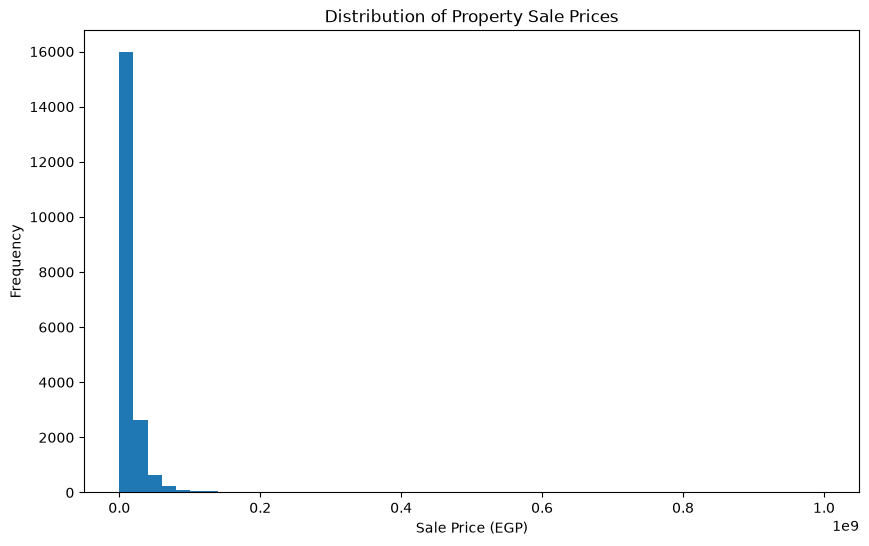

In [59]:
print("Buy Price Distribution:")
plt.figure(figsize=(10, 6))

plt.hist(buy_df['price_egp'], bins=50)

plt.xlabel('Sale Price (EGP)')
plt.ylabel('Frequency')
plt.title('Distribution of Property Sale Prices')

plt.show()

Rent Price Distribution


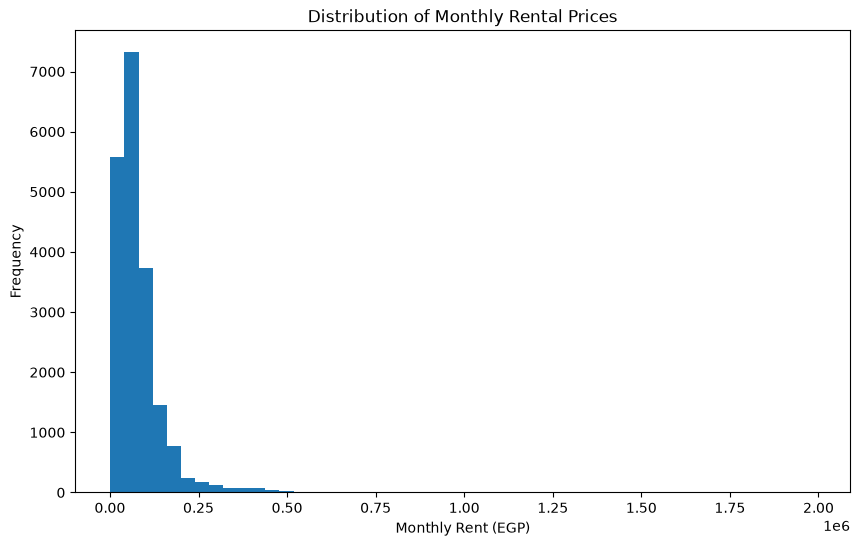

In [60]:
print("Rent Price Distribution")
plt.figure(figsize=(10, 6))

plt.hist(rent_df['price_egp'], bins=50)

plt.xlabel('Monthly Rent (EGP)')
plt.ylabel('Frequency')
plt.title('Distribution of Monthly Rental Prices')

plt.show()

In [61]:
print("Buy price skewness:",
      buy_df['price_egp'].skew())


Buy price skewness: 16.50629380267638


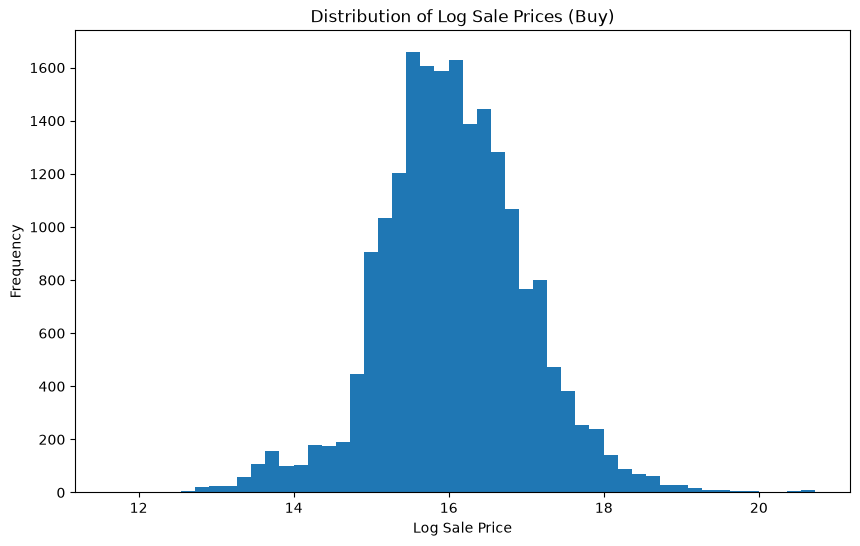

In [62]:
plt.figure(figsize=(10, 6))

plt.hist(np.log1p(buy_df['price_egp']), bins=50)

plt.xlabel('Log Sale Price')
plt.ylabel('Frequency')
plt.title('Distribution of Log Sale Prices (Buy)')

plt.show()

In [63]:
print("Rent price skewness:",
      rent_df['price_egp'].skew())

Rent price skewness: 6.581028745083357


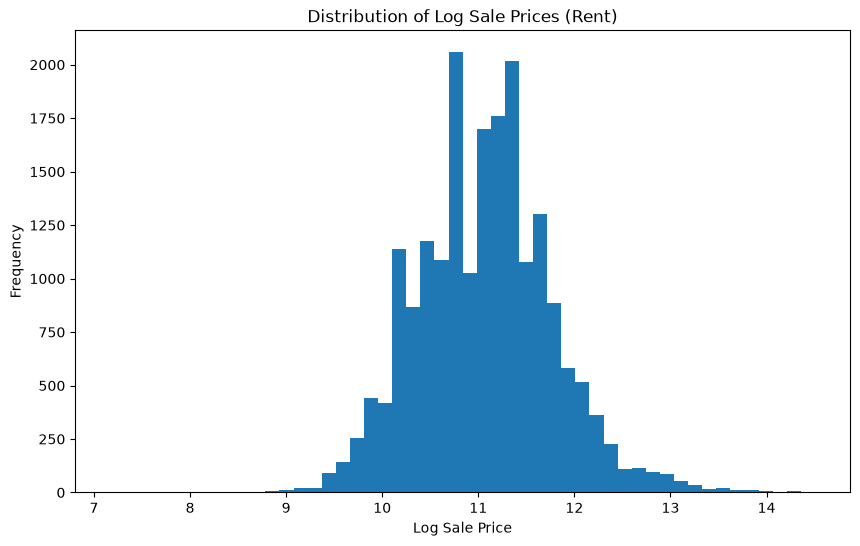

In [64]:
plt.figure(figsize=(10, 6))

plt.hist(np.log1p(rent_df['price_egp']), bins=50)

plt.xlabel('Log Sale Price')
plt.ylabel('Frequency')
plt.title('Distribution of Log Sale Prices (Rent)')

plt.show()

### 3. Compare Property Types in Buy vs Rent

In [65]:
property_comparison = pd.DataFrame({
    'Buy': buy_df['property_type'].value_counts(),
    'Rent': rent_df['property_type'].value_counts()
}).fillna(0)

property_comparison

,Buy,Rent
property_type,,
Apartment,10509.0,14620.0
Bulk Rent Unit,0.0,1.0
Bulk Sale Unit,3.0,0.0
Bungalow,0.0,2.0
Cabin,15.0,4.0
Chalet,1589.0,72.0
Duplex,648.0,891.0
Full Floor,1.0,0.0
Half Floor,3.0,0.0


In [66]:
property_pct = pd.DataFrame({
    'Buy %': buy_df['property_type']
                   .value_counts(normalize=True) * 100,

    'Rent %': rent_df['property_type']
                    .value_counts(normalize=True) * 100
}).fillna(0)

property_pct.round(2)

,Buy %,Rent %
property_type,,
Apartment,53.07,73.90
Bulk Rent Unit,0.00,0.01
Bulk Sale Unit,0.02,0.00
Bungalow,0.00,0.01
Cabin,0.08,0.02
Chalet,8.02,0.36
Duplex,3.27,4.50
Full Floor,0.01,0.00
Half Floor,0.02,0.00


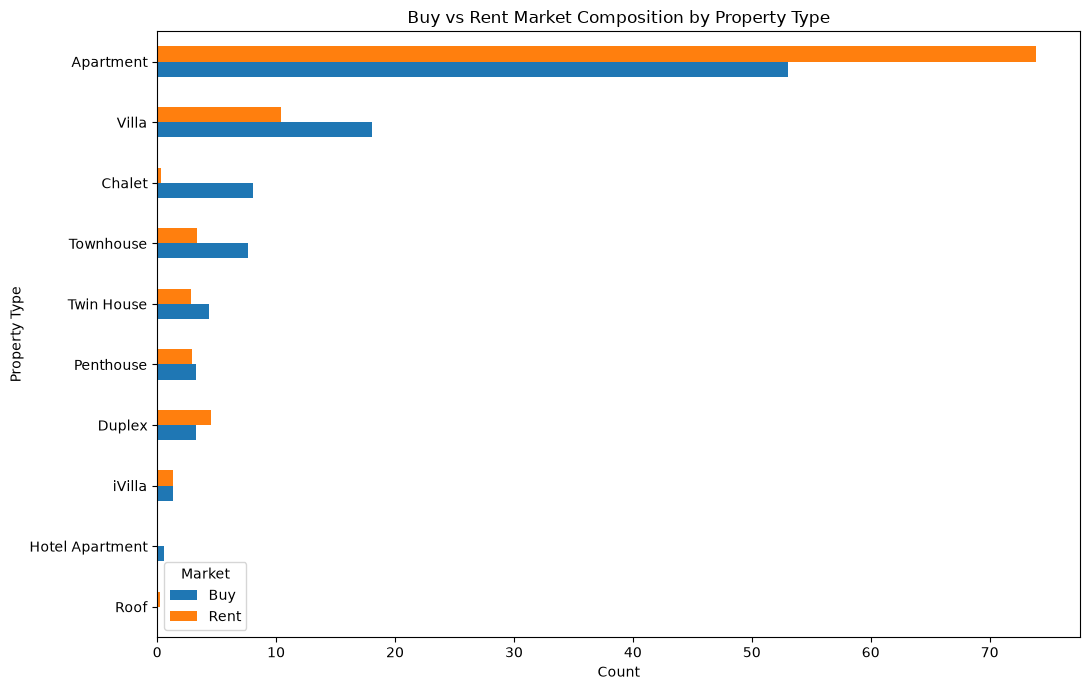

In [67]:
buy_property_pct = (
    buy_df['property_type']
    .value_counts(normalize=True)
    .mul(100)
)

rent_property_pct = (
    rent_df['property_type']
    .value_counts(normalize=True)
    .mul(100)
)

# Combine both markets
property_market_comparison = pd.DataFrame({
    'Buy': buy_property_pct,
    'Rent': rent_property_pct
}).fillna(0)

# Keep the most important property types
top_types = (
    property_market_comparison
    .sum(axis=1)
    .sort_values(ascending=False)
    .head(10)
    .index
)

plot_data = property_market_comparison.loc[top_types]

# Plot
ax = plot_data.sort_values('Buy').plot(
    kind='barh',
    figsize=(11, 7)
)

plt.title('Buy vs Rent Market Composition by Property Type')
plt.xlabel('Count')
plt.ylabel('Property Type')
plt.legend(title='Market')
plt.tight_layout()
plt.show()

### 4. Compare Cities — Buy vs Rent

In [68]:
city_comparison = pd.DataFrame({
    'Buy Listings': buy_df['city'].value_counts(),
    'Rent Listings': rent_df['city'].value_counts()
}).fillna(0)

city_comparison

,Buy Listings,Rent Listings
city,,
Al Daqahlya,1,0.0
Alexandria,322,146.0
Cairo,9858,15920.0
Demyat,1,0.0
Giza,5928,3577.0
Matrouh,3,0.0
North Coast,1683,118.0
Qalyubia,43,1.0
Red Sea,1415,15.0


In [69]:
# percentage of cities in buy and rent with order
city_pct = pd.DataFrame({
    'Buy %': buy_df['city']
                 .value_counts(normalize=True) * 100,

    'Rent %': rent_df['city']
                  .value_counts(normalize=True) * 100
}).fillna(0)

city_pct.round(2)

,Buy %,Rent %
city,,
Al Daqahlya,0.01,0.00
Alexandria,1.63,0.74
Cairo,49.78,80.47
Demyat,0.01,0.00
Giza,29.94,18.08
Matrouh,0.02,0.00
North Coast,8.50,0.60
Qalyubia,0.22,0.01
Red Sea,7.15,0.08


<Figure size 1000x600 with 0 Axes>

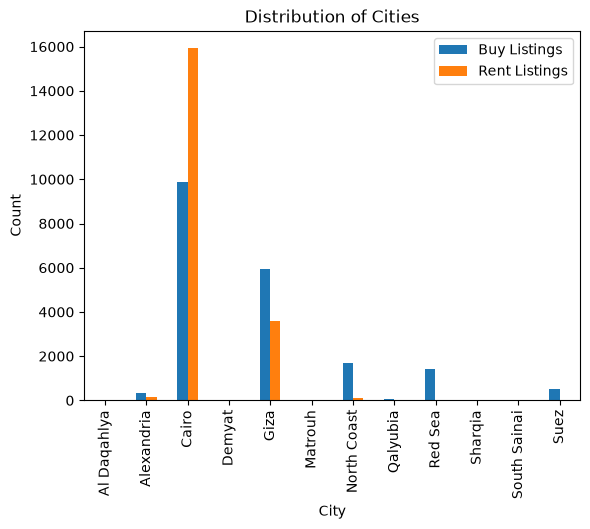

In [70]:
plt.figure(figsize=(10, 6))

city_comparison.plot(kind='bar')

plt.xlabel('City')
plt.ylabel('Count')
plt.title('Distribution of Cities')

plt.show()

### 5. Median Sale Price by City

In [71]:
buy_city_price = (
    buy_df
    .groupby('city')['price_egp']
    .agg(['count', 'mean', 'median', 'std'])
    .sort_values('median', ascending=False)
)

buy_city_price.round(2)

,count,mean,median,std
city,,,,
North Coast,1683,20159868.51,12000000.0,40441797.82
Cairo,9858,17442452.01,10000000.0,35336285.80
Giza,5928,14497221.25,8312000.0,31092321.44
Alexandria,322,9475236.90,7775000.0,6786137.60
Suez,511,8185829.42,7200000.0,6243928.53
Red Sea,1415,10195408.47,6676800.0,11280693.71
Al Daqahlya,1,5400000.00,5400000.0,NaN
Demyat,1,5200000.00,5200000.0,NaN
South Sainai,32,4882528.44,4915000.0,3129120.02


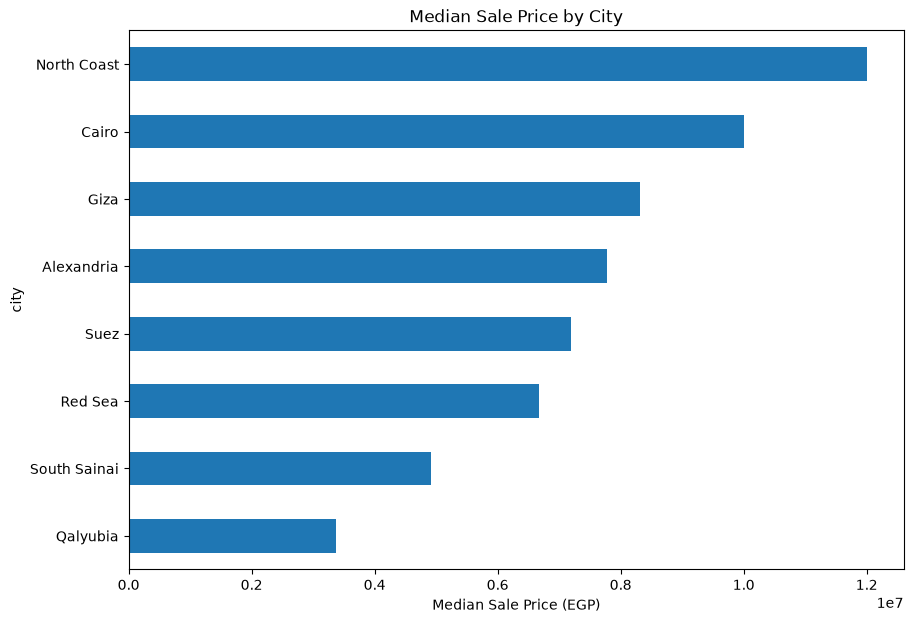

In [72]:
plot_data = buy_city_price[
    buy_city_price['count'] >= 30
]

plt.figure(figsize=(10, 7))

plot_data['median'].sort_values().plot(
    kind='barh'
)

plt.xlabel('Median Sale Price (EGP)')
plt.title('Median Sale Price by City')

plt.show()

### 6. Median Monthly Rent by City

In [73]:
rent_city_price = (
    rent_df
    .groupby('city')['price_egp']
    .agg(['count', 'mean', 'median', 'std'])
    .sort_values('median', ascending=False)
)

rent_city_price.round(2)

,count,mean,median,std
city,,,,
North Coast,118,601495.76,507500.0,455032.18
Cairo,15920,84706.61,70000.0,71733.91
Giza,3577,65668.15,50000.0,55801.51
Suez,6,64166.67,50000.0,50538.76
Red Sea,15,70840.93,50000.0,90102.32
Alexandria,146,33173.34,25000.0,27283.01
Qalyubia,1,3000.00,3000.0,NaN


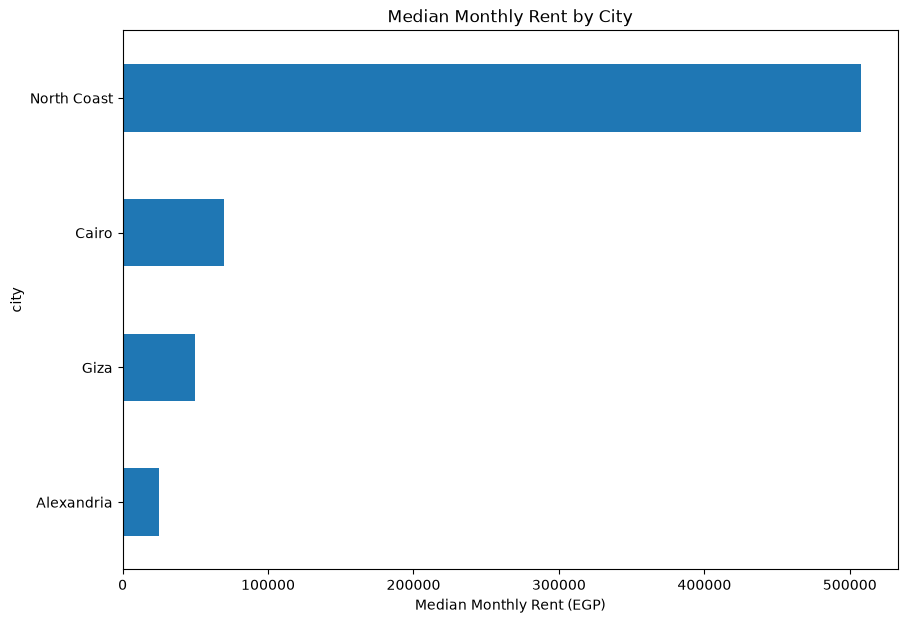

In [74]:
plot_data = rent_city_price[
    rent_city_price['count'] >= 30
]

plt.figure(figsize=(10, 7))

plot_data['median'].sort_values().plot(
    kind='barh'
)

plt.xlabel('Median Monthly Rent (EGP)')
plt.title('Median Monthly Rent by City')

plt.show()

### 7.Median listed sale price vs median listed monthly rent in each city

In [75]:
city_market_comparison = pd.DataFrame({
    'Median Sale Price':
        buy_df.groupby('city')['price_egp'].median(),

    'Median Monthly Rent':
        rent_df.groupby('city')['price_egp'].median(),

    'Sale Listings':
        buy_df.groupby('city').size(),

    'Rent Listings':
        rent_df.groupby('city').size()
})

city_market_comparison.round(2)

,Median Sale Price,Median Monthly Rent,Sale Listings,Rent Listings
city,,,,
Al Daqahlya,5400000.0,NaN,1,NaN
Alexandria,7775000.0,25000.0,322,146.0
Cairo,10000000.0,70000.0,9858,15920.0
Demyat,5200000.0,NaN,1,NaN
Giza,8312000.0,50000.0,5928,3577.0
Matrouh,1936000.0,NaN,3,NaN
North Coast,12000000.0,507500.0,1683,118.0
Qalyubia,3370000.0,3000.0,43,1.0
Red Sea,6676800.0,50000.0,1415,15.0


### 8. Property Type vs Price — Buy

In [76]:
buy_property_price = (
    buy_df
    .groupby('property_type')['price_egp']
    .agg(['count', 'mean', 'median', 'std'])
    .sort_values('median', ascending=False)
)

buy_property_price.round(2)

,count,mean,median,std
property_type,,,,
Palace,10,2.781650e+08,167500000.0,3.283915e+08
Land,29,1.876394e+08,67500000.0,2.988843e+08
Whole Building,35,1.163806e+08,28000000.0,2.348114e+08
Villa,3572,3.700899e+07,26000000.0,5.148990e+07
Bulk Sale Unit,3,2.816667e+07,25000000.0,2.539849e+07
Full Floor,1,2.400000e+07,24000000.0,NaN
Twin House,855,2.496432e+07,22500000.0,1.542125e+07
Townhouse,1512,1.863512e+07,16775000.0,1.950325e+07
Duplex,648,1.271182e+07,11811825.0,7.858846e+06


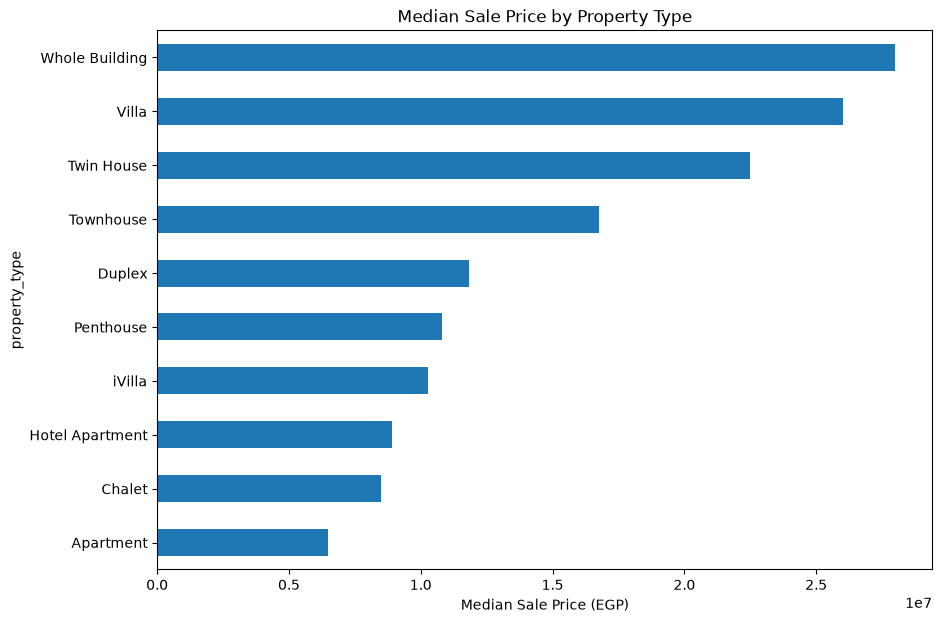

In [77]:
plot_data = buy_property_price[
    buy_property_price['count'] >= 30
]

plt.figure(figsize=(10, 7))

plot_data['median'].sort_values().plot(
    kind='barh'
)

plt.xlabel('Median Sale Price (EGP)')
plt.title('Median Sale Price by Property Type')

plt.show()

### 9. Property Type vs Rent

In [78]:
rent_property_price = (
    rent_df
    .groupby('property_type')['price_egp']
    .agg(['count', 'mean', 'median', 'std'])
    .sort_values('median', ascending=False)
)

rent_property_price.round(2)

,count,mean,median,std
property_type,,,,
Chalet,72,544076.39,450000.0,400384.21
Cabin,4,385000.00,397500.0,314722.10
Palace,4,437500.00,350000.0,209662.43
Villa,2056,199956.73,165000.0,144515.98
Whole Building,5,438000.00,150000.0,448505.85
Twin House,568,143653.50,125000.0,97937.09
Townhouse,665,119738.24,110000.0,64506.58
Duplex,891,85638.77,80000.0,37661.42
Bulk Rent Unit,1,80000.00,80000.0,NaN


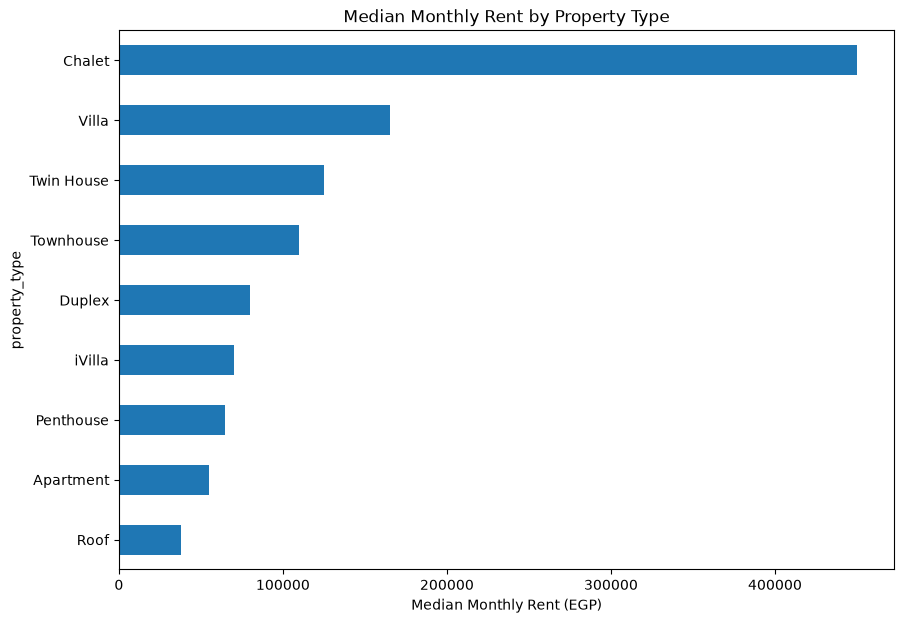

In [79]:
plot_data = rent_property_price[
    rent_property_price['count'] >= 30
]

plt.figure(figsize=(10, 7))

plot_data['median'].sort_values().plot(
    kind='barh'
)

plt.xlabel('Median Monthly Rent (EGP)')
plt.title('Median Monthly Rent by Property Type')

plt.show()

### 10. Bedrooms vs Price

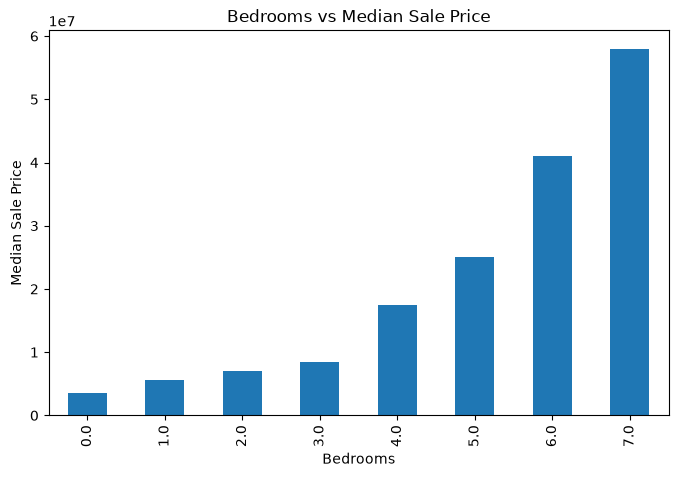

In [80]:
buy_bedroom_price = (
    buy_df
    .groupby('bedrooms')['price_egp']
    .median()
)

buy_bedroom_price.plot(
    kind='bar',
    figsize=(8,5)
)

plt.xlabel('Bedrooms')
plt.ylabel('Median Sale Price')
plt.title('Bedrooms vs Median Sale Price')

plt.show()

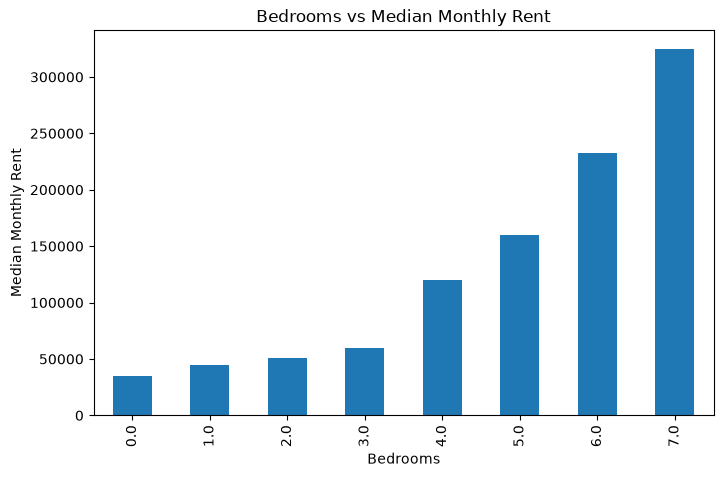

In [81]:
rent_bedroom_price = (
    rent_df
    .groupby('bedrooms')['price_egp']
    .median()
)

rent_bedroom_price.plot(
    kind='bar',
    figsize=(8,5)
)

plt.xlabel('Bedrooms')
plt.ylabel('Median Monthly Rent')
plt.title('Bedrooms vs Median Monthly Rent')

plt.show()

### 11. Correlation Matrix

In [82]:
corr_features = [
    'price_egp',
    'area_value',
    'bedrooms',
    'bathrooms',
    'images_count'
]

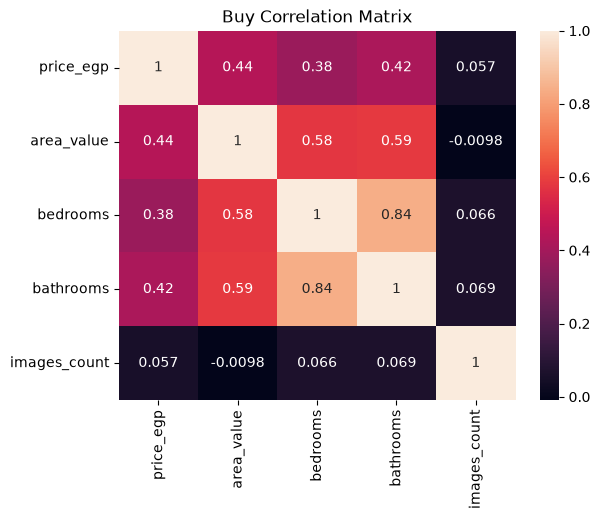

In [83]:
buy_corr = (
    buy_df[corr_features]
    .corr()
)
sns.heatmap(buy_corr, annot=True)
plt.title("Buy Correlation Matrix")
plt.show()

In [84]:
buy_corr['price_egp'].sort_values(
    ascending=False
)

price_egp       1.000000
area_value      0.440679
bathrooms       0.418557
bedrooms        0.379544
images_count    0.057071
Name: price_egp, dtype: float64

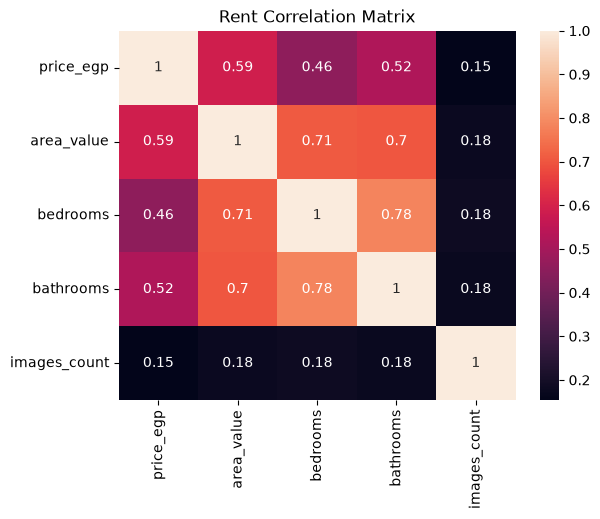

In [85]:
rent_corr = (
    rent_df[corr_features]
    .corr()
)
sns.heatmap(rent_corr, annot=True)
plt.title("Rent Correlation Matrix")
plt.show()

In [86]:
rent_corr['price_egp'].sort_values(
    ascending=False
)

price_egp       1.000000
area_value      0.589079
bathrooms       0.519211
bedrooms        0.455897
images_count    0.153398
Name: price_egp, dtype: float64

### 12.  Furnished

In [87]:
rent_furnished = (
    rent_df
    .groupby('furnished')['price_egp']
    .agg(['count', 'mean', 'median', 'std'])
)

rent_furnished.round(2)

,count,mean,median,std
furnished,,,,
NO,2886,53165.69,35000.0,62102.56
PARTLY,5539,88213.86,65000.0,70020.07
Unknown,136,91773.52,70000.0,81915.40
YES,11222,89659.66,70000.0,98249.12


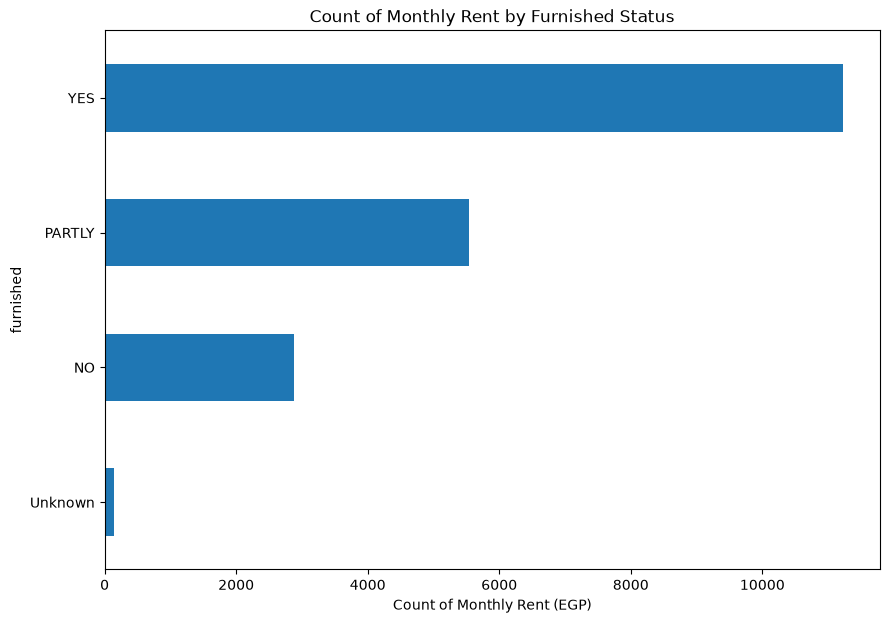

In [88]:
plot_data = rent_furnished[
    rent_furnished['count'] >= 30
]

plt.figure(figsize=(10, 7))

plot_data['count'].sort_values().plot(
    kind='barh'
)

plt.xlabel('Count of Monthly Rent (EGP)')
plt.title('Count of Monthly Rent by Furnished Status')

plt.show()

In [89]:
market_comparison = pd.DataFrame({
    'Buy': [
        len(buy_df),
        buy_df['area_value'].median(),
        buy_df['bedrooms'].median(),
        buy_df['bathrooms'].median()
    ],
    
    'Rent': [
        len(rent_df),
        rent_df['area_value'].median(),
        rent_df['bedrooms'].median(),
        rent_df['bathrooms'].median()
    ]
}, index=[
    'Listings',
    'Median Area',
    'Median Bedrooms',
    'Median Bathrooms'
])

display(market_comparison.round(2))

,Buy,Rent
Listings,19802.0,19783.0
Median Area,166.0,186.0
Median Bedrooms,3.0,3.0
Median Bathrooms,3.0,3.0


### Boxplots — Before Clipping

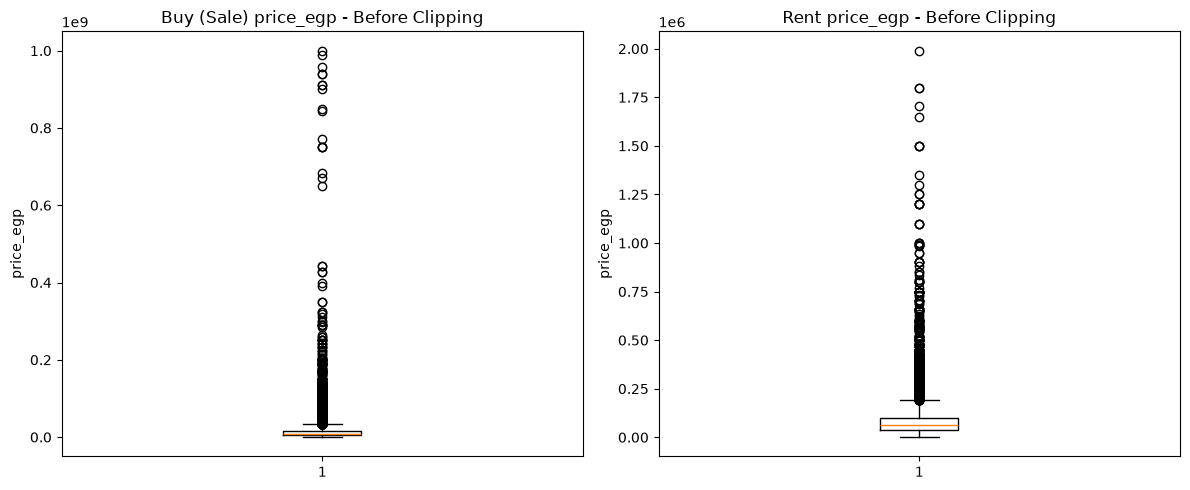

In [90]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].boxplot(buy_df['price_egp'].dropna())
axes[0].set_title('Buy (Sale) price_egp - Before Clipping')
axes[0].set_ylabel('price_egp')

axes[1].boxplot(rent_df['price_egp'].dropna())
axes[1].set_title('Rent price_egp - Before Clipping')
axes[1].set_ylabel('price_egp')

plt.tight_layout()
plt.show()

# PART II — Modeling & Evaluation

This section starts **after the team's Cleaning and EDA work**. It uses the cleaned dataframe `df` produced above and keeps the modeling workflow reproducible and leakage-safe.

The target is `price_egp`. Sale and Rent are modeled separately. `category`, `offering_type`, `price_period`, and any target-derived field are excluded from predictive features.

In [91]:
import re
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from catboost import CatBoostRegressor


## 1. Modeling Decisions

- Target: `price_egp`
- Problem type: regression
- Two separate markets: Sale and Rent
- `price_per_sqm` is excluded because it is derived from the target price and would cause target leakage.
- IDs, URLs, contact fields, raw title/description text, `scraped_at`, and market-period columns are excluded from predictors.
- We keep a compact structured feature set: property attributes, city/district, coordinates, amenities count, listing status, and simple date features.
- Numeric missing values are imputed inside the pipeline using the training data only.
- Categorical variables are imputed and one-hot encoded inside the pipeline.
- A chronological split is used to simulate predicting later listings from earlier listings.

## 4. Feature Engineering

Feature engineering is kept simple and leakage-safe. The rental-market quality audit is handled before modeling; the original `title` field is not used as a predictive feature.


In [92]:
df_model = df.copy()

def count_amenities(value):
    if pd.isna(value) or str(value).strip() == "" or str(value).strip().lower() == "unknown":
        return 0
    parts = [x.strip() for x in re.split(r"[,;|]", str(value)) if x.strip()]
    return len(set(parts))

# -----------------------------
# Leakage-safe feature engineering
# -----------------------------
df_model["amenities_count"] = df_model["amenities"].apply(count_amenities)
df_model["total_rooms"] = df_model["bedrooms"] + df_model["bathrooms"]

df_model["listed_year"] = df_model["listed_date"].dt.year
df_model["listed_month"] = df_model["listed_date"].dt.month
df_model["listed_dayofweek"] = df_model["listed_date"].dt.dayofweek

# Nonlinear property-size features
df_model["area_per_bedroom"] = (
    df_model["area_value"] / df_model["bedrooms"].replace(0, np.nan)
)
df_model["bathrooms_per_bedroom"] = (
    df_model["bathrooms"] / df_model["bedrooms"].replace(0, np.nan)
)
df_model["log_area"] = np.log1p(df_model["area_value"].clip(lower=0))

# Location transformations
df_model["lat_squared"] = df_model["lat"] ** 2
df_model["lon_squared"] = df_model["lon"] ** 2
df_model["lat_lon_interaction"] = df_model["lat"] * df_model["lon"]

# A coarser coordinate bucket gives the model local spatial information
df_model["location_grid"] = (
    df_model["lat"].round(2).astype("string").fillna("Unknown")
    + "_"
    + df_model["lon"].round(2).astype("string").fillna("Unknown")
)

df_model = df_model.dropna(subset=["price_egp"]).copy()

# -----------------------------
# Feature sets
# -----------------------------
MODEL_FEATURES = [
    "area_value", "bedrooms", "bathrooms", "total_rooms",
    "property_type", "furnished", "city", "district",
    "lat", "lon", "amenities_count", "completion_status",
    "listing_level", "is_premium", "is_new_construction",
    "is_direct_from_dev", "is_exclusive", "images_count",
    "listed_year", "listed_month"
]

# Enhanced features are now tested for BOTH markets.
# town/subdistrict are especially useful for Sale because location strongly
# affects property value.
ENHANCED_FEATURES = MODEL_FEATURES + [
    "area_per_bedroom",
    "bathrooms_per_bedroom",
    "log_area",
    "lat_squared",
    "lon_squared",
    "lat_lon_interaction",
    "location_grid",
    "town",
    "subdistrict",
    "listed_dayofweek"
]

SALE_ENHANCED_FEATURES = ENHANCED_FEATURES
RENT_ENHANCED_FEATURES = ENHANCED_FEATURES

FORBIDDEN_FEATURES = [
    "price_egp", "price_per_sqm", "category", "offering_type", "price_period",
    "listing_type", "scraped_at", "listing_id", "internal_id", "detail_url",
    "reference", "description", "title"
]

for feature_set_name, feature_set in {
    "MODEL_FEATURES": MODEL_FEATURES,
    "SALE_ENHANCED_FEATURES": SALE_ENHANCED_FEATURES,
    "RENT_ENHANCED_FEATURES": RENT_ENHANCED_FEATURES,
}.items():
    assert not set(feature_set) & set(FORBIDDEN_FEATURES), (
        f"Forbidden/leakage feature found in {feature_set_name}"
    )

print("Core model features:", len(MODEL_FEATURES))
print("Enhanced features:", len(ENHANCED_FEATURES))
print("Leakage checks passed.")


Core model features: 20
Enhanced features: 30
Leakage checks passed.


### Why these engineered features?

The core features capture the main property characteristics, while the enhanced set adds:

- `town` and `subdistrict` for more detailed location information.
- `area_per_bedroom` and `bathrooms_per_bedroom` for property-layout relationships.
- `log_area` for the nonlinear effect of property size.
- `lat_squared`, `lon_squared`, and `lat_lon_interaction` for nonlinear spatial effects.
- `location_grid` for local geographic grouping.
- `listed_dayofweek` as a small time-related signal.

All of these are target-independent, so they do not use `price_egp` or `price_per_sqm`.
The enhanced feature set is evaluated for both Sale and Rent using the same chronological validation strategy.


## 5. Split Sale and Rent

In [93]:
buy_df = df_model[df_model["category"].eq("buy")].copy()
rent_df = df_model[df_model["category"].eq("rent")].copy()

print("Sale listings:", len(buy_df))
print("Rent listings:", len(rent_df))

Sale listings: 19802
Rent listings: 19783


In [94]:
df_rent = df[df['category'] == 'rent'].copy()

Q1 = df_rent['price_egp'].quantile(0.25)
Q3 = df_rent['price_egp'].quantile(0.75)

IQR = Q3 - Q1

lower_fence_rent = Q1 - 1.5 * IQR
upper_fence_rent = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Fence:", lower_fence_rent)
print("Upper Fence:", upper_fence_rent)

Q1: 40000.0
Q3: 100000.0
IQR: 60000.0
Lower Fence: -50000.0
Upper Fence: 190000.0


In [95]:
outliers = rent_df[
    (rent_df['price_egp'] < lower_fence_rent) |
    (rent_df['price_egp'] > upper_fence_rent)
]
print("Number of potential outliers:", len(outliers))

Number of potential outliers: 1156


In [96]:
rent_df['price_egp'] = rent_df['price_egp'].clip(lower=lower_fence_rent, upper=upper_fence_rent)
buy_df['price_egp'] = buy_df['price_egp'].clip(lower=lower_fence_sell, upper=upper_fence_sell)

### Boxplots — After Clipping

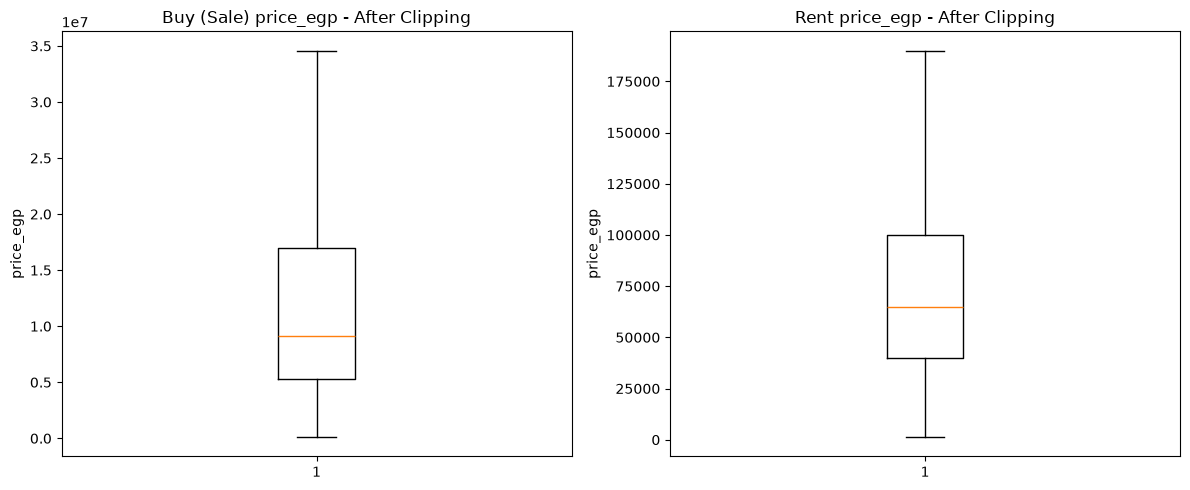

In [97]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].boxplot(buy_df['price_egp'].dropna())
axes[0].set_title('Buy (Sale) price_egp - After Clipping')
axes[0].set_ylabel('price_egp')

axes[1].boxplot(rent_df['price_egp'].dropna())
axes[1].set_title('Rent price_egp - After Clipping')
axes[1].set_ylabel('price_egp')

plt.tight_layout()
plt.show()

## 6. Chronological Train / Validation / Test Split

The data are sorted by `listed_date`.

- 70% oldest listings → training
- next 15% → validation
- newest 15% → test

The test set is kept untouched until the final evaluation.

In [98]:
def chronological_split(data, train_frac=0.70, val_frac=0.15):
    data = data.dropna(subset=["listed_date"]).sort_values("listed_date").reset_index(drop=True)
    n = len(data)
    train_end = int(n * train_frac)
    val_end = int(n * (train_frac + val_frac))
    return (
        data.iloc[:train_end].copy(),
        data.iloc[train_end:val_end].copy(),
        data.iloc[val_end:].copy()
    )

buy_train, buy_val, buy_test = chronological_split(buy_df)
rent_train, rent_val, rent_test = chronological_split(rent_df)

for name, part in [
    ("Sale train", buy_train), ("Sale validation", buy_val), ("Sale test", buy_test),
    ("Rent train", rent_train), ("Rent validation", rent_val), ("Rent test", rent_test)
]:
    print(f"{name:18s}: {len(part):,} rows | {part['listed_date'].min()} -> {part['listed_date'].max()}")


Sale train        : 13,861 rows | 2022-07-02 10:28:05+00:00 -> 2026-03-03 10:00:40+00:00
Sale validation   : 2,970 rows | 2026-03-03 10:00:44+00:00 -> 2026-03-04 06:59:18+00:00
Sale test         : 2,971 rows | 2026-03-04 06:59:55+00:00 -> 2026-03-04 15:52:39+00:00
Rent train        : 13,848 rows | 2022-06-08 22:00:31+00:00 -> 2026-02-26 04:57:32+00:00
Rent validation   : 2,967 rows | 2026-02-26 05:07:49+00:00 -> 2026-03-02 10:24:29+00:00
Rent test         : 2,968 rows | 2026-03-02 10:24:29+00:00 -> 2026-03-04 23:42:53+00:00


## 7. Preprocessing

The preprocessing is inside a `Pipeline`, so statistics such as medians and category vocabularies are learned from the training data rather than from the validation/test sets.

In [99]:
def make_preprocessor_for(features):
    categorical = [
        c for c in features
        if df_model[c].dtype == "object" or pd.api.types.is_string_dtype(df_model[c])
    ]
    numeric = [c for c in features if c not in categorical]

    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median"))
    ])

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            min_frequency=10
        ))
    ])

    return ColumnTransformer([
        ("num", numeric_pipeline, numeric),
        ("cat", categorical_pipeline, categorical)
    ])

def make_preprocessor():
    return make_preprocessor_for(MODEL_FEATURES)

CATEGORICAL_FEATURES = [
    c for c in MODEL_FEATURES
    if df_model[c].dtype == "object" or pd.api.types.is_string_dtype(df_model[c])
]
NUMERIC_FEATURES = [c for c in MODEL_FEATURES if c not in CATEGORICAL_FEATURES]

print("Core categorical features:", CATEGORICAL_FEATURES)
print("Core numeric features:", NUMERIC_FEATURES)


Core categorical features: ['property_type', 'furnished', 'city', 'district', 'completion_status', 'listing_level']
Core numeric features: ['area_value', 'bedrooms', 'bathrooms', 'total_rooms', 'lat', 'lon', 'amenities_count', 'is_premium', 'is_new_construction', 'is_direct_from_dev', 'is_exclusive', 'images_count', 'listed_year', 'listed_month']


## 8. Evaluation Metrics

In [100]:
def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }

def inverse_log_prediction(model, X):
    # Do not clip to the training target maximum.
    # Clipping can artificially suppress legitimate high-price predictions,
    # especially in the Sale market where expensive properties are common.
    log_pred = model.predict(X)
    return np.maximum(np.expm1(log_pred), 0)


## 9. Model Benchmark

We benchmark four model families:

1. Linear Regression — simple baseline
2. Random Forest — nonlinear tree ensemble
3. Gradient Boosting — sequential nonlinear tree model
4. CatBoost — strong categorical-friendly tree model

The four models are compared separately for Sale and Rent using the same validation split and the same metrics.

In [101]:
def build_sklearn_models():
    return {
        "Linear Regression": Pipeline([
            ("preprocessor", make_preprocessor()),
            ("model", LinearRegression())
        ]),
        "Random Forest": Pipeline([
            ("preprocessor", make_preprocessor()),
            ("model", RandomForestRegressor(
                n_estimators=100,
                max_depth=16,
                min_samples_leaf=2,
                max_features=1.0,
                random_state=42,
                n_jobs=-1
            ))
        ]),
        "Gradient Boosting": Pipeline([
            ("preprocessor", make_preprocessor()),
            ("model", GradientBoostingRegressor(
                n_estimators=80,
                learning_rate=0.05,
                max_depth=3,
                min_samples_leaf=3,
                loss="huber",
                random_state=42
            ))
        ])
    }

def prepare_catboost_data(train_df, other_df, features):
    categorical = [
        c for c in features
        if df_model[c].dtype == "object" or pd.api.types.is_string_dtype(df_model[c])
    ]
    numeric = [c for c in features if c not in categorical]

    train_x = train_df[features].copy()
    other_x = other_df[features].copy()

    for c in categorical:
        train_x[c] = train_x[c].fillna("Missing").astype(str)
        other_x[c] = other_x[c].fillna("Missing").astype(str)

    for c in numeric:
        median_value = train_df[c].median()
        train_x[c] = train_x[c].fillna(median_value)
        other_x[c] = other_x[c].fillna(median_value)

    return train_x, other_x, categorical

def benchmark_market(market_name, train_df, val_df):
    X_train = train_df[MODEL_FEATURES]
    X_val = val_df[MODEL_FEATURES]
    y_train = np.log1p(train_df["price_egp"].values)
    y_val = val_df["price_egp"].values

    rows = []
    fitted = {}

    for name, model in build_sklearn_models().items():
        start = time.time()
        model.fit(X_train, y_train)
        pred = inverse_log_prediction(model, X_val)

        row = {
            "Market": market_name,
            "Model": name,
            **regression_metrics(y_val, pred),
            "Train_Time_sec": round(time.time() - start, 2)
        }
        rows.append(row)
        fitted[name] = model

    # CatBoost benchmark with core features
    train_x, val_x, cat_features = prepare_catboost_data(
        train_df, val_df, MODEL_FEATURES
    )

    start = time.time()
    cat_model = CatBoostRegressor(
        iterations=300,
        depth=7,
        learning_rate=0.05,
        loss_function="RMSE",
        random_seed=42,
        verbose=False,
        allow_writing_files=False
    )

    cat_model.fit(
        train_x,
        y_train,
        cat_features=cat_features
    )

    cat_pred = np.maximum(np.expm1(cat_model.predict(val_x)), 0)

    rows.append({
        "Market": market_name,
        "Model": "CatBoost",
        **regression_metrics(y_val, cat_pred),
        "Train_Time_sec": round(time.time() - start, 2)
    })
    fitted["CatBoost"] = cat_model

    return pd.DataFrame(rows), fitted

sale_benchmark, sale_models = benchmark_market("Sale", buy_train, buy_val)
rent_benchmark, rent_models = benchmark_market("Rent", rent_train, rent_val)

benchmark_results = pd.concat(
    [sale_benchmark, rent_benchmark],
    ignore_index=True
)

display(
    benchmark_results.sort_values(
        ["Market", "R2"],
        ascending=[True, False]
    ).reset_index(drop=True).round(4)
)


,Market,Model,MAE,RMSE,R2,Train_Time_sec
0,Rent,Random Forest,1.273564e+04,2.013519e+04,8.309000e-01,5.73
1,Rent,CatBoost,1.398903e+04,2.128333e+04,8.110000e-01,13.45
2,Rent,Gradient Boosting,1.852435e+04,2.726591e+04,6.899000e-01,2.41
3,Rent,Linear Regression,2.056564e+04,3.205882e+04,5.712000e-01,0.22
4,Sale,Random Forest,2.433652e+06,3.930593e+06,8.362000e-01,7.93
5,Sale,CatBoost,2.673494e+06,4.090217e+06,8.226000e-01,14.49
6,Sale,Gradient Boosting,3.390844e+06,4.905506e+06,7.449000e-01,2.61
7,Sale,Linear Regression,5.267625e+35,2.029916e+37,-4.368842e+60,0.25


### Benchmark conclusion

The benchmark is used only as a starting point. The final model is selected using the controlled validation experiments below.

Because the main goal of this project is predictive performance, **R² is the primary model-selection metric**, while MAE and RMSE are also reported to describe absolute prediction error.

We then test whether the enhanced property and location features improve Sale and Rent.


## 10. Targeted Hyperparameter Tuning

Random Forest is tuned on the validation set using several sensible configurations.

The search is still targeted rather than exhaustive. The main selection criterion is **validation R²**, because improving explained variance is the main modeling goal.


In [102]:
TUNING_CONFIGS = [
    {
        "n_estimators": 100,
        "max_depth": 14,
        "min_samples_leaf": 3,
        "max_features": 1.0
    },
    {
        "n_estimators": 150,
        "max_depth": 16,
        "min_samples_leaf": 2,
        "max_features": 1.0
    },
    {
        "n_estimators": 200,
        "max_depth": 18,
        "min_samples_leaf": 2,
        "max_features": 1.0
    },
    {
        "n_estimators": 200,
        "max_depth": None,
        "min_samples_leaf": 2,
        "max_features": 0.8
    },
    {
        "n_estimators": 250,
        "max_depth": 20,
        "min_samples_leaf": 1,
        "max_features": 0.8
    }
]

def targeted_tune_random_forest(train_df, val_df, features):
    y_train = np.log1p(train_df["price_egp"].values)
    y_val = val_df["price_egp"].values

    preprocessor = make_preprocessor_for(features)

    X_train = preprocessor.fit_transform(
        train_df[features],
        y_train
    )
    X_val = preprocessor.transform(
        val_df[features]
    )

    rows = []
    best_row = None
    best_cfg = None

    for cfg in TUNING_CONFIGS:
        start = time.time()

        model = RandomForestRegressor(
            random_state=42,
            n_jobs=-1,
            **cfg
        )

        model.fit(X_train, y_train)

        pred = np.maximum(
            np.expm1(model.predict(X_val)),
            0
        )

        metrics = regression_metrics(y_val, pred)

        row = {
            **cfg,
            **metrics,
            "Train_Time_sec": round(time.time() - start, 2)
        }
        rows.append(row)

        # Primary selection criterion: highest validation R2
        if best_row is None or metrics["R2"] > best_row["R2"]:
            best_row = metrics
            best_cfg = cfg

    results = pd.DataFrame(rows)
    return results, best_cfg

# Sale: tune on the enhanced Sale feature set
sale_tuning, sale_best_cfg = targeted_tune_random_forest(
    buy_train,
    buy_val,
    SALE_ENHANCED_FEATURES
)

print("Sale tuning — enhanced features")
display(
    sale_tuning.sort_values("R2", ascending=False).round(4)
)
print("Best Sale configuration:", sale_best_cfg)

# Rent: tune on the enhanced Rent feature set
rent_tuning, rent_best_cfg = targeted_tune_random_forest(
    rent_train,
    rent_val,
    RENT_ENHANCED_FEATURES
)

print("\nRent tuning — enhanced features")
display(
    rent_tuning.sort_values("R2", ascending=False).round(4)
)
print("Best Rent configuration:", rent_best_cfg)


Sale tuning — enhanced features


,n_estimators,max_depth,min_samples_leaf,max_features,MAE,RMSE,R2,Train_Time_sec
3,200,NaN,2,0.8,2.344845e+06,3.804820e+06,0.8465,26.52
4,250,20.0,1,0.8,2.337493e+06,3.809776e+06,0.8461,46.09
2,200,18.0,2,1.0,2.394292e+06,3.858882e+06,0.8421,28.04
1,150,16.0,2,1.0,2.414256e+06,3.868308e+06,0.8413,19.74
0,100,14.0,3,1.0,2.485893e+06,3.930038e+06,0.8362,9.98


Best Sale configuration: {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 2, 'max_features': 0.8}

Rent tuning — enhanced features


,n_estimators,max_depth,min_samples_leaf,max_features,MAE,RMSE,R2,Train_Time_sec
4,250,20.0,1,0.8,12403.1031,19869.4101,0.8353,32.22
3,200,NaN,2,0.8,12439.5322,19960.2981,0.8338,21.28
2,200,18.0,2,1.0,12703.0257,20187.3192,0.8300,22.19
1,150,16.0,2,1.0,12916.9574,20404.0904,0.8263,13.31
0,100,14.0,3,1.0,13494.8646,21073.4944,0.8147,6.81


Best Rent configuration: {'n_estimators': 250, 'max_depth': 20, 'min_samples_leaf': 1, 'max_features': 0.8}


### What did tuning actually prove?

The table above is the source of truth.

For each market, the configuration with the **highest validation R²** is selected. MAE and RMSE are retained as secondary error measures.

This avoids assuming in advance that the original 40-tree configuration is the best one.


## 11. Feature Engineering Experiment

We test the effect of the enhanced features separately from the core feature set.

The same train/validation split and the same Random Forest configuration are used for both variants.


In [103]:
def fit_rf_validation_features(train_df, val_df, features, cfg):
    y_train = np.log1p(train_df["price_egp"].values)
    y_val = val_df["price_egp"].values

    prep = make_preprocessor_for(features)
    X_train = prep.fit_transform(train_df[features], y_train)
    X_val = prep.transform(val_df[features])

    model = RandomForestRegressor(
        random_state=42,
        n_jobs=-1,
        **cfg
    )

    model.fit(X_train, y_train)

    pred = np.maximum(
        np.expm1(model.predict(X_val)),
        0
    )

    return regression_metrics(y_val, pred)

# Sale: core vs enhanced
sale_core_val = fit_rf_validation_features(
    buy_train,
    buy_val,
    MODEL_FEATURES,
    sale_best_cfg
)

sale_enhanced_val = fit_rf_validation_features(
    buy_train,
    buy_val,
    SALE_ENHANCED_FEATURES,
    sale_best_cfg
)

sale_feature_experiment = pd.DataFrame([
    {"Variant": "Core features", **sale_core_val},
    {"Variant": "Enhanced property + location", **sale_enhanced_val},
])

print("Sale feature experiment — validation set")
display(sale_feature_experiment.round(4))

# Rent: core vs enhanced
rent_core_val = fit_rf_validation_features(
    rent_train,
    rent_val,
    MODEL_FEATURES,
    rent_best_cfg
)

rent_enhanced_val = fit_rf_validation_features(
    rent_train,
    rent_val,
    RENT_ENHANCED_FEATURES,
    rent_best_cfg
)

rent_feature_experiment = pd.DataFrame([
    {"Variant": "Core features", **rent_core_val},
    {"Variant": "Enhanced property + location", **rent_enhanced_val},
])

print("Rent feature experiment — validation set")
display(rent_feature_experiment.round(4))


Sale feature experiment — validation set


,Variant,MAE,RMSE,R2
0,Core features,2.403373e+06,3.894627e+06,0.8392
1,Enhanced property + location,2.344845e+06,3.804820e+06,0.8465


Rent feature experiment — validation set


,Variant,MAE,RMSE,R2
0,Core features,12341.3438,19728.7537,0.8376
1,Enhanced property + location,12403.1031,19869.4101,0.8353


## 12. Final Model Fit and Untouched Test Evaluation

After model selection and feature experiments, the final Random Forest is refit on **Train + Validation** and evaluated once on the untouched chronological Test set.


In [104]:
FINAL_CONFIGS = {
    "Sale": sale_best_cfg,
    "Rent": rent_best_cfg
}

FINAL_FEATURES = {
    "Sale": SALE_ENHANCED_FEATURES,
    "Rent": RENT_ENHANCED_FEATURES
}

def fit_final_rf_and_evaluate(train_df, val_df, test_df, cfg, features):
    combined = pd.concat(
        [train_df, val_df],
        ignore_index=True
    )

    y_train = np.log1p(combined["price_egp"].values)

    model = Pipeline([
        ("preprocessor", make_preprocessor_for(features)),
        ("model", RandomForestRegressor(
            random_state=42,
            n_jobs=-1,
            **cfg
        ))
    ])

    model.fit(combined[features], y_train)

    pred = inverse_log_prediction(
        model,
        test_df[features]
    )

    return (
        model,
        pred,
        regression_metrics(
            test_df["price_egp"],
            pred
        )
    )

sale_final_model, sale_test_pred, sale_test_metrics = fit_final_rf_and_evaluate(
    buy_train,
    buy_val,
    buy_test,
    FINAL_CONFIGS["Sale"],
    FINAL_FEATURES["Sale"]
)

rent_final_model, rent_test_pred, rent_test_metrics = fit_final_rf_and_evaluate(
    rent_train,
    rent_val,
    rent_test,
    FINAL_CONFIGS["Rent"],
    FINAL_FEATURES["Rent"]
)

final_results = pd.DataFrame([
    {
        "Market": "Sale",
        "Model": "Random Forest + enhanced features",
        **sale_test_metrics
    },
    {
        "Market": "Rent",
        "Model": "Random Forest + enhanced features",
        **rent_test_metrics
    },
])

display(final_results.round(2))


,Market,Model,MAE,RMSE,R2
0,Sale,Random Forest + enhanced features,2496186.60,3975698.09,0.83
1,Rent,Random Forest + enhanced features,11239.98,18444.98,0.84


### Interpretation of the final test results

The final test table above is the **single source of truth** for the reported Sale and Rent performance.

The test set was kept untouched during feature engineering and hyperparameter selection.

Report all three metrics:
- **R²**: proportion of price variance explained by the model.
- **MAE**: average absolute prediction error in EGP.
- **RMSE**: penalizes large prediction errors more strongly.

Do not manually type old metric values into the notebook; use the executed `final_results` table.


## 13. Business Baseline Comparison

We compare the final models against a simple median-price baseline learned only from Train + Validation. This answers the business question: does the ML model add meaningful predictive value over a naive reference estimate?

In [105]:
def median_baseline_result(train_df, val_df, test_df):
    baseline_value = pd.concat([train_df, val_df])["price_egp"].median()
    pred = np.full(len(test_df), baseline_value)
    return baseline_value, regression_metrics(test_df["price_egp"], pred)

sale_baseline_value, sale_baseline_metrics = median_baseline_result(buy_train, buy_val, buy_test)
rent_baseline_value, rent_baseline_metrics = median_baseline_result(rent_train, rent_val, rent_test)

baseline_table = pd.DataFrame([
    {"Market": "Sale", "Type": "Median baseline", "Reference": f"{sale_baseline_value:,.0f} EGP", **sale_baseline_metrics},
    {"Market": "Sale", "Type": "Final Random Forest", "Reference": "Final model", **sale_test_metrics},
    {"Market": "Rent", "Type": "Median baseline", "Reference": f"{rent_baseline_value:,.0f} EGP", **rent_baseline_metrics},
    {"Market": "Rent", "Type": "Final Random Forest", "Reference": "Enhanced features", **rent_test_metrics},
])

display(baseline_table.round(2))
print(f"Rent MAE improvement vs median baseline: {(1 - rent_test_metrics['MAE'] / rent_baseline_metrics['MAE']) * 100:.2f}%")

,Market,Type,Reference,MAE,RMSE,R2
0,Sale,Median baseline,"9,000,000 EGP",7473195.03,10470093.15,-0.19
1,Sale,Final Random Forest,Final model,2496186.60,3975698.09,0.83
2,Rent,Median baseline,"65,000 EGP",34805.75,46566.50,-0.02
3,Rent,Final Random Forest,Enhanced features,11239.98,18444.98,0.84


Rent MAE improvement vs median baseline: 67.71%


## 14. Rental Temporal Stability Check

Because the primary split is chronological, we test forward validation windows to see whether rental performance is reasonably consistent across time. This is a diagnostic robustness check; the final test set remains untouched.

In [106]:
def rolling_rent_validation(features, cfg):
    r = rent_df.dropna(subset=["listed_date", "price_egp"]).sort_values("listed_date").reset_index(drop=True)
    n = len(r)
    windows = [
        ("Fold 1", int(0.60 * n), int(0.70 * n)),
        ("Fold 2", int(0.70 * n), int(0.80 * n)),
        ("Fold 3", int(0.80 * n), n),
    ]

    rows = []
    for fold_name, train_end, val_end in windows:
        tr = r.iloc[:train_end].copy()
        va = r.iloc[train_end:val_end].copy()
        metrics = fit_rf_validation_features(tr, va, features, cfg)
        rows.append({"Fold": fold_name, "Train rows": len(tr), "Validation rows": len(va), **metrics})

    return pd.DataFrame(rows)

rent_stability = rolling_rent_validation(RENT_ENHANCED_FEATURES, rent_best_cfg)
display(rent_stability.round(2))

,Fold,Train rows,Validation rows,MAE,RMSE,R2
0,Fold 1,11869,1979,12138.67,19295.15,0.84
1,Fold 2,13848,1978,12992.87,20948.19,0.82
2,Fold 3,15826,3957,11196.14,18094.74,0.85


## 15. Error Analysis by Price Segment

Error analysis is performed on the quality-controlled test sets. For rent, the final metrics and error bands therefore describe the cleaned rental population used for deployment-style evaluation.


In [107]:
def error_table(test_df, predictions):
    out = test_df[["price_egp", "property_type", "city"]].copy()
    out["predicted_price"] = predictions
    out["absolute_error"] = np.abs(out["predicted_price"] - out["price_egp"])
    out["absolute_percentage_error"] = out["absolute_error"] / np.maximum(out["price_egp"], 1)
    out["price_band"] = pd.qcut(
        out["price_egp"],
        q=5,
        labels=["Lowest", "Low", "Middle", "High", "Highest"],
        duplicates="drop"
    )
    return out

def summarize_error_bands(errors):
    return errors.groupby("price_band", observed=False).agg(
        MAE=("absolute_error", "mean"),
        Median_AE=("absolute_error", "median"),
        Within_20=("absolute_percentage_error", lambda x: (x <= 0.20).mean()),
        Listings=("absolute_error", "size")
    ).reset_index()

sale_errors = error_table(buy_test, sale_test_pred)
rent_errors = error_table(rent_test, rent_test_pred)

print("Sale error by price band")
display(summarize_error_bands(sale_errors).round(4))

print("Rent error by price band")
display(summarize_error_bands(rent_errors).round(4))

Sale error by price band


,price_band,MAE,Median_AE,Within_20,Listings
0,Lowest,1.137107e+06,7.145864e+05,0.4885,610
1,Low,1.292898e+06,8.648893e+05,0.6564,582
2,Middle,1.992243e+06,1.448444e+06,0.5990,591
3,High,3.436708e+06,2.630908e+06,0.5791,594
4,Highest,4.631731e+06,3.232098e+06,0.6801,594


Rent error by price band


,price_band,MAE,Median_AE,Within_20,Listings
0,Lowest,6183.6080,3944.1841,0.6073,741
1,Low,7408.9221,4890.2932,0.7328,494
2,Middle,8959.7258,6255.0870,0.7754,561
3,High,12183.9434,8076.0262,0.7699,578
4,Highest,21968.8165,14409.4343,0.7323,594


## 16. Actual vs Predicted Visualization

The plots below should be generated from the untouched test set. A perfect model would place observations close to the diagonal line.

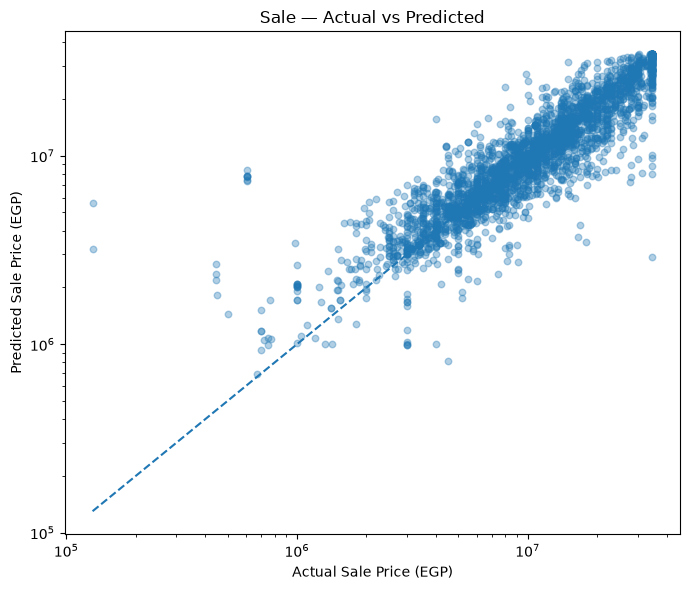

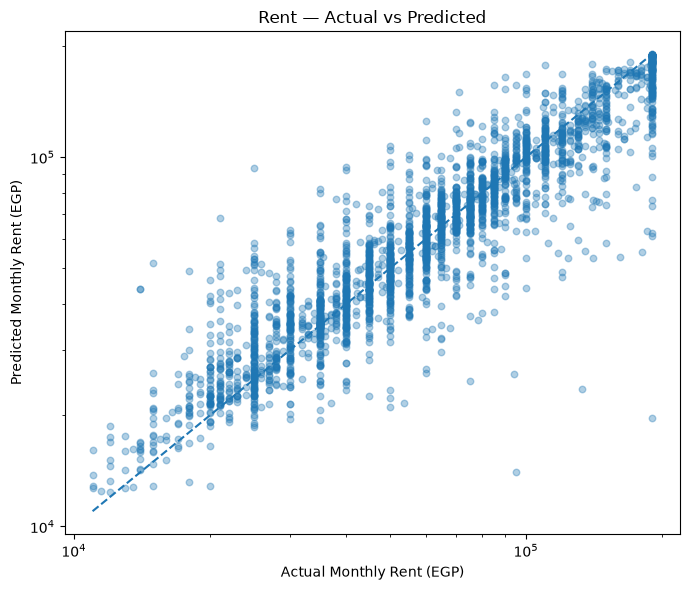

In [108]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(buy_test["price_egp"], sale_test_pred, alpha=0.35, s=22)
lo = max(1, min(buy_test["price_egp"].min(), sale_test_pred.min()))
hi = max(buy_test["price_egp"].max(), sale_test_pred.max())
ax.plot([lo, hi], [lo, hi], linestyle="--")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Actual Sale Price (EGP)")
ax.set_ylabel("Predicted Sale Price (EGP)")
ax.set_title("Sale — Actual vs Predicted")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(rent_test["price_egp"], rent_test_pred, alpha=0.35, s=22)
lo = max(1, min(rent_test["price_egp"].min(), rent_test_pred.min()))
hi = max(rent_test["price_egp"].max(), rent_test_pred.max())
ax.plot([lo, hi], [lo, hi], linestyle="--")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Actual Monthly Rent (EGP)")
ax.set_ylabel("Predicted Monthly Rent (EGP)")
ax.set_title("Rent — Actual vs Predicted")
plt.tight_layout()
plt.show()

## 17. Feature Importance

Feature importance is shown for the final Random Forest models. For one-hot encoded variables, the displayed names correspond to the encoded feature columns.

In [109]:
def show_feature_importance(model, title, top_n=12):
    prep = model.named_steps["preprocessor"]
    rf = model.named_steps["model"]
    names = prep.get_feature_names_out()
    importance = pd.DataFrame({"Feature": names, "Importance": rf.feature_importances_})
    importance = importance.sort_values("Importance", ascending=False).head(top_n)
    print(title)
    display(importance)
    return importance

sale_importance = show_feature_importance(sale_final_model, "Top Sale features")
rent_importance = show_feature_importance(rent_final_model, "Top Rent features")

Top Sale features


,Feature,Importance
16,num__log_area,0.295609
0,num__area_value,0.287389
19,num__lat_lon_interaction,0.041580
21,cat__property_type_Apartment,0.033119
6,num__amenities_count,0.027671
14,num__area_per_bedroom,0.022938
36,cat__furnished_Unknown,0.019229
546,cat__subdistrict_5th Settlement Compounds,0.015427
2,num__bathrooms,0.015324
3,num__total_rooms,0.014274


Top Rent features


,Feature,Importance
0,num__area_value,0.228741
16,num__log_area,0.202710
31,cat__furnished_NO,0.094449
19,num__lat_lon_interaction,0.033376
3,num__total_rooms,0.028103
14,num__area_per_bedroom,0.027587
15,num__bathrooms_per_bedroom,0.024709
2,num__bathrooms,0.023948
5,num__lon,0.023259
34,cat__furnished_YES,0.022642


## 18. Business Price Estimator

The estimator accepts the same structured inputs used by the final models and returns a reference price in EGP.

In [110]:
def prepare_input_record(record, features):
    x = pd.DataFrame([record]).copy()

    for c in ["bedrooms", "bathrooms", "area_value", "lat", "lon"]:
        if c not in x.columns:
            x[c] = np.nan

    x["total_rooms"] = x["bedrooms"] + x["bathrooms"]

    x["area_per_bedroom"] = (
        x["area_value"] / x["bedrooms"].replace(0, np.nan)
    )
    x["bathrooms_per_bedroom"] = (
        x["bathrooms"] / x["bedrooms"].replace(0, np.nan)
    )
    x["log_area"] = np.log1p(x["area_value"].clip(lower=0))

    if "amenities_count" not in x.columns:
        x["amenities_count"] = (
            count_amenities(x["amenities"].iloc[0])
            if "amenities" in x.columns else 0
        )

    x["lat_squared"] = x["lat"] ** 2
    x["lon_squared"] = x["lon"] ** 2
    x["lat_lon_interaction"] = x["lat"] * x["lon"]

    x["location_grid"] = (
        x["lat"].round(2).astype("string").fillna("Unknown")
        + "_"
        + x["lon"].round(2).astype("string").fillna("Unknown")
    )

    if "listed_date" in x.columns:
        d = pd.to_datetime(x["listed_date"], errors="coerce")
        x["listed_year"] = d.dt.year
        x["listed_month"] = d.dt.month
        x["listed_dayofweek"] = d.dt.dayofweek

    for c in features:
        if c not in x.columns:
            x[c] = np.nan

    return x[features]

def estimate_price(record, market):
    features = FINAL_FEATURES[market]
    model = sale_final_model if market == "Sale" else rent_final_model

    x = prepare_input_record(record, features)
    prediction_log = model.predict(x)[0]

    return float(max(np.expm1(prediction_log), 0))

example_property = {
    "area_value": 170,
    "bedrooms": 3,
    "bathrooms": 2,
    "property_type": "Apartment",
    "furnished": "YES",
    "city": "Cairo",
    "district": "The 5th Settlement",
    "town": np.nan,
    "subdistrict": np.nan,
    "lat": 30.03,
    "lon": 31.47,
    "amenities_count": 8,
    "completion_status": "completed",
    "listing_level": "premium",
    "is_premium": True,
    "is_new_construction": False,
    "is_direct_from_dev": False,
    "is_exclusive": False,
    "images_count": 10,
    "listed_date": "2026-03-04"
}

print(
    f"Estimated Sale Price: "
    f"{estimate_price(example_property, 'Sale'):,.0f} EGP"
)

print(
    f"Estimated Monthly Rent: "
    f"{estimate_price(example_property, 'Rent'):,.0f} EGP"
)


Estimated Sale Price: 6,857,432 EGP
Estimated Monthly Rent: 54,433 EGP


## 19. Final Modeling Summary

The final submission combines the team's Cleaning + EDA work first, followed by the modeling and evaluation stage.

### What was tested

- Cleaning and EDA before modeling.
- Data-quality checks for duplicates, repeated references, and rental inconsistencies.
- Leakage-safe target definition.
- Core structured features.
- Enhanced property and location features for **both Sale and Rent**.
- Four benchmark model families.
- Targeted Random Forest hyperparameter tuning.
- Model selection using validation **R²**.
- Core-vs-enhanced feature experiments.
- Median-price business baseline.
- Forward temporal stability diagnostic for Rent.
- Final refit on Train + Validation.
- One untouched chronological Test evaluation.
- Error analysis, actual-vs-predicted visualization, feature importance, and a reference-price estimator.

### Important modeling rule

`price_per_sqm` is not used as a predictor because it is calculated from the target price and would create target leakage.

### Final results

The executed `final_results` table is the authoritative source for the final Sale and Rent MAE, RMSE, and R² values.


## Final Run Check

Before submission, use **Restart Kernel → Run All** so every output in this combined notebook is generated in one clean execution. The final tables should be treated as the authoritative metrics for the presentation.